# This file contains data analyasis performed over full dataset

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from load_data import load_data_file, load_data_directory

## Data Directory Paths

In [2]:
DATA_DIR = 'data/Dhruv_Patel/'
BEDROOM_DIR = f'{DATA_DIR}/Bedroom'
HALL_DIR = f'{DATA_DIR}/Hall'
KITCHEN_DIR = f'{DATA_DIR}/Kitchen'
PLOT_DIR = f'{DATA_DIR}/Plots'

## Load data for all 3 rooms

In [3]:
def get_data(roomPath=None):
    """
    Loads data for the given room using `roomPath` to access the data
    """
    if roomPath is None:
        raise ValueError("parameter roomPath is None")
    else:
        data = load_data_directory(roomPath)
        dfs = []
        if data is not None:
            for file_name, df in data.items():
                if df is not None:
                    dfs.append(df)
        if dfs:
            return pd.concat(dfs, ignore_index=True)


# Load Kitchen data
kitchen_df = get_data(KITCHEN_DIR)
# Load Hall data
hall_df = get_data(HALL_DIR)
# Load Bedroom data
bedroom_df = get_data(BEDROOM_DIR)

Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2025-12-31.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-01.csv, with 7851 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-02.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-03.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-04.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-05.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-06.csv, with 7851 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel//Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-07.csv, with 78

## Multi-Day Time Series (Foundation Plot)
- Plot Pm2.5atm vs Time for all three rooms on the same graph
  - For this first make it so that we have avrage value of PM2.5atm per minute
  - then plot new PM2.5atm vs time one sub plot for each room
  - save it at `data/Dhruv_Patel/Plots/Multi_Day_Time_Series`

### Remove outliers

In [4]:
def remove_outliers_iqr(df, column, threshold):
    df_clean = df[df[column] <= threshold].copy()
    return df_clean

In [5]:
def multi_day_time_series(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    
    # Create a list of only the `DateTime` and `pm2.5atm` columns for each room
    bedroom_df_subset = bedroom_df[['DateTime', 'pm2.5atm']]
    hall_df_subset = hall_df[['DateTime', 'pm2.5atm']]
    kitchen_df_subset = kitchen_df[['DateTime', 'pm2.5atm']]

    # Take perminute average of `pm2.5atm` for each room
    bedroom_df_subset['DateTime'] = pd.to_datetime(bedroom_df_subset['DateTime'])
    bedroom_df_subset.set_index('DateTime', inplace=True)
    bedroom_df_subset = bedroom_df_subset.resample('1min').mean()

    hall_df_subset['DateTime'] = pd.to_datetime(hall_df_subset['DateTime'])
    hall_df_subset.set_index('DateTime', inplace=True)
    hall_df_subset = hall_df_subset.resample('1min').mean()

    kitchen_df_subset['DateTime'] = pd.to_datetime(kitchen_df_subset['DateTime'])
    kitchen_df_subset.set_index('DateTime', inplace=True)
    kitchen_df_subset = kitchen_df_subset.resample('1min').mean()

    bedroom_df_subset = remove_outliers_iqr(bedroom_df_subset, 'pm2.5atm', 200)
    hall_df_subset = remove_outliers_iqr(hall_df_subset, 'pm2.5atm', 1500)
    kitchen_df_subset = remove_outliers_iqr(kitchen_df_subset, 'pm2.5atm', 1500)

    # Plot the perminute average of `pm2.5atm` for each room in a subplot with a shared x-axis
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    ax1.plot(bedroom_df_subset.index, bedroom_df_subset['pm2.5atm'], label='Bedroom', alpha=0.7, color='blue')
    ax1.set_ylabel('Per Minute Average of pm2.5atm')
    ax1.set_title('Bedroom')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(hall_df_subset.index, hall_df_subset['pm2.5atm'], label='Hall', alpha=0.7, color='orange')
    ax2.set_ylabel('Per Minute Average of pm2.5atm')
    ax2.set_title('Hall')
    ax2.legend()
    ax2.grid(alpha=0.3)

    ax3.plot(kitchen_df_subset.index, kitchen_df_subset['pm2.5atm'], label='Kitchen', alpha=0.7, color='green')
    ax3.set_xlabel('DateTime')
    ax3.set_ylabel('Per Minute Average of pm2.5atm')
    ax3.set_title('Kitchen')
    ax3.legend()
    ax3.grid(alpha=0.3)

    plt.suptitle('Per Minute Average of pm2.5atm for Each Room')
    plt.tight_layout()
    # Save the plot
    os.makedirs(f'{PLOT_DIR}/Multi_Day_Time_Series', exist_ok=True)
    plt.savefig(f'{PLOT_DIR}/Multi_Day_Time_Series/pm25_per_minute_average.png', dpi=300, bbox_inches='tight')
    plt.show()

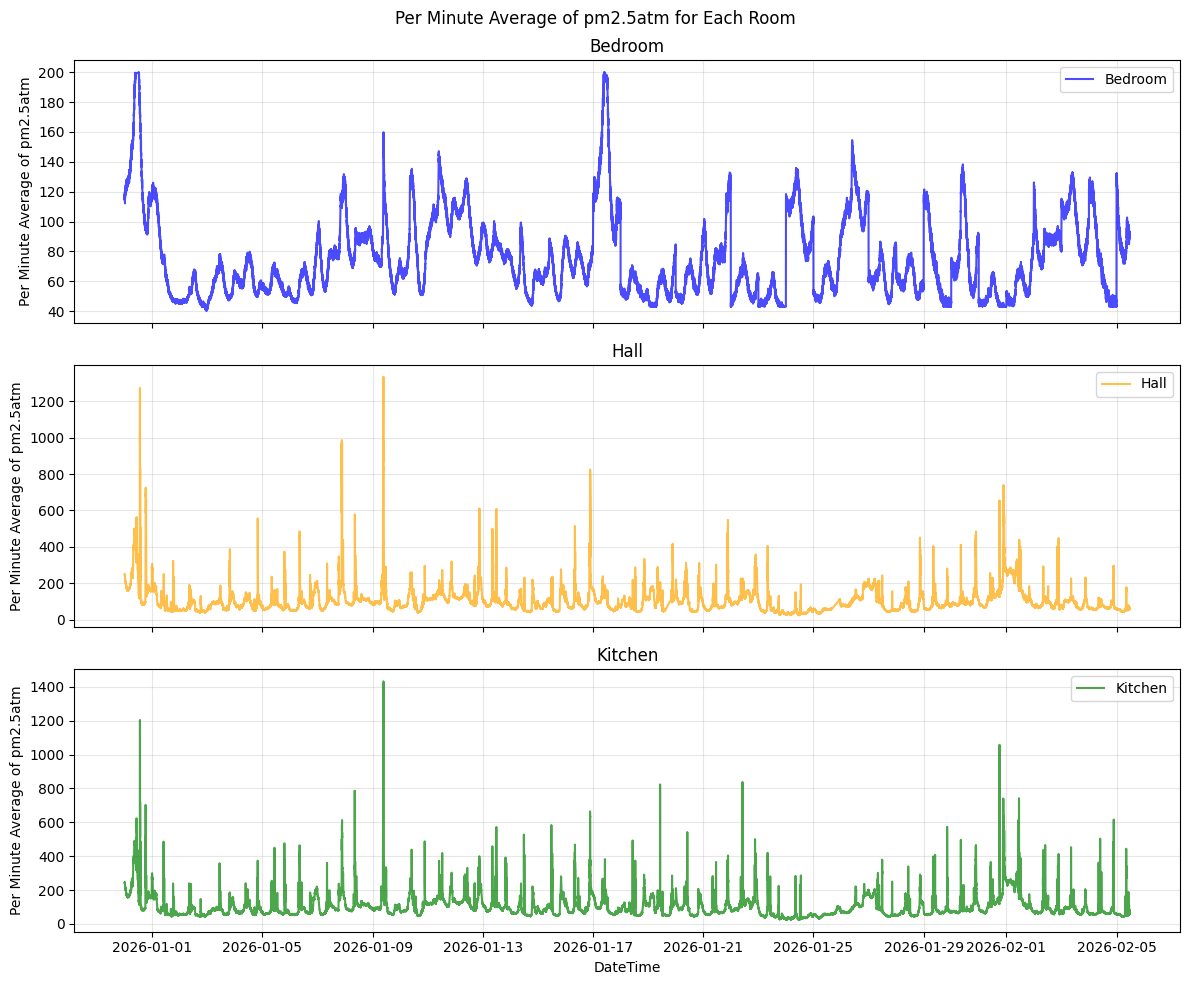

In [6]:
# Call the function
multi_day_time_series(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

## Daily Average Trend Plot (Very Important)
- For each day compute:
  - Daily mean PM2.5
  - Daily max PM2.5

- Plot daily mean & max Vs date in same graph

In [7]:
def daily_average_trend_plot(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")
    
    # Create a list of only the `DateTime` and `pm2.5atm` columns for each room
    bedroom_df_subset = bedroom_df[['DateTime', 'pm2.5atm']]
    hall_df_subset = hall_df[['DateTime', 'pm2.5atm']]
    kitchen_df_subset = kitchen_df[['DateTime', 'pm2.5atm']]

    # Calculate daily average and max of `pm2.5atm` for each room
    bedroom_df_subset['DateTime'] = pd.to_datetime(bedroom_df_subset['DateTime'])
    bedroom_df_subset.set_index('DateTime', inplace=True)
    bedroom_daily_avg = bedroom_df_subset.resample('D').mean()
    bedroom_daily_max = bedroom_df_subset.resample('D').max()

    hall_df_subset['DateTime'] = pd.to_datetime(hall_df_subset['DateTime'])
    hall_df_subset.set_index('DateTime', inplace=True)
    hall_daily_avg = hall_df_subset.resample('D').mean()
    hall_daily_max = hall_df_subset.resample('D').max()

    kitchen_df_subset['DateTime'] = pd.to_datetime(kitchen_df_subset['DateTime'])
    kitchen_df_subset.set_index('DateTime', inplace=True)
    kitchen_daily_avg = kitchen_df_subset.resample('D').mean()
    kitchen_daily_max = kitchen_df_subset.resample('D').max()

    # Plot the daily average and max of `pm2.5atm` for each room in a subplot with a shared x-axis
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    ax1.plot(bedroom_daily_avg.index, bedroom_daily_avg['pm2.5atm'], label='Bedroom Daily Average', alpha=0.7, color='blue')
    ax1.plot(bedroom_daily_max.index, bedroom_daily_max['pm2.5atm'], label='Bedroom Daily Max', alpha=0.7, color='red')
    ax1.set_ylabel('Daily Average and Max of pm2.5atm')
    ax1.set_title('Bedroom')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(hall_daily_avg.index, hall_daily_avg['pm2.5atm'], label='Hall Daily Average', alpha=0.7, color='orange')
    ax2.plot(hall_daily_max.index, hall_daily_max['pm2.5atm'], label='Hall Daily Max', alpha=0.7, color='red')
    ax2.set_ylabel('Daily Average and Max of pm2.5atm')
    ax2.set_title('Hall')
    ax2.legend()
    ax2.grid(alpha=0.3)


    ax3.plot(kitchen_daily_avg.index, kitchen_daily_avg['pm2.5atm'], label='Kitchen Daily Average', alpha=0.7, color='green')
    ax3.plot(kitchen_daily_max.index, kitchen_daily_max['pm2.5atm'], label='Kitchen Daily Max', alpha=0.7, color='red')
    ax3.set_ylabel('Daily Average and Max of pm2.5atm')
    ax3.set_title('Kitchen')
    ax3.legend()
    ax3.grid(alpha=0.3)
    plt.suptitle('Daily Average and Max of pm2.5atm for Each Room')
    plt.tight_layout()
    # Save the plot
    os.makedirs(f'{PLOT_DIR}/Daily_Average_Trend_Plot', exist_ok=True)
    plt.savefig(f'{PLOT_DIR}/Daily_Average_Trend_Plot/pm25_daily_avg_max.png', dpi=300, bbox_inches='tight')
    plt.show()

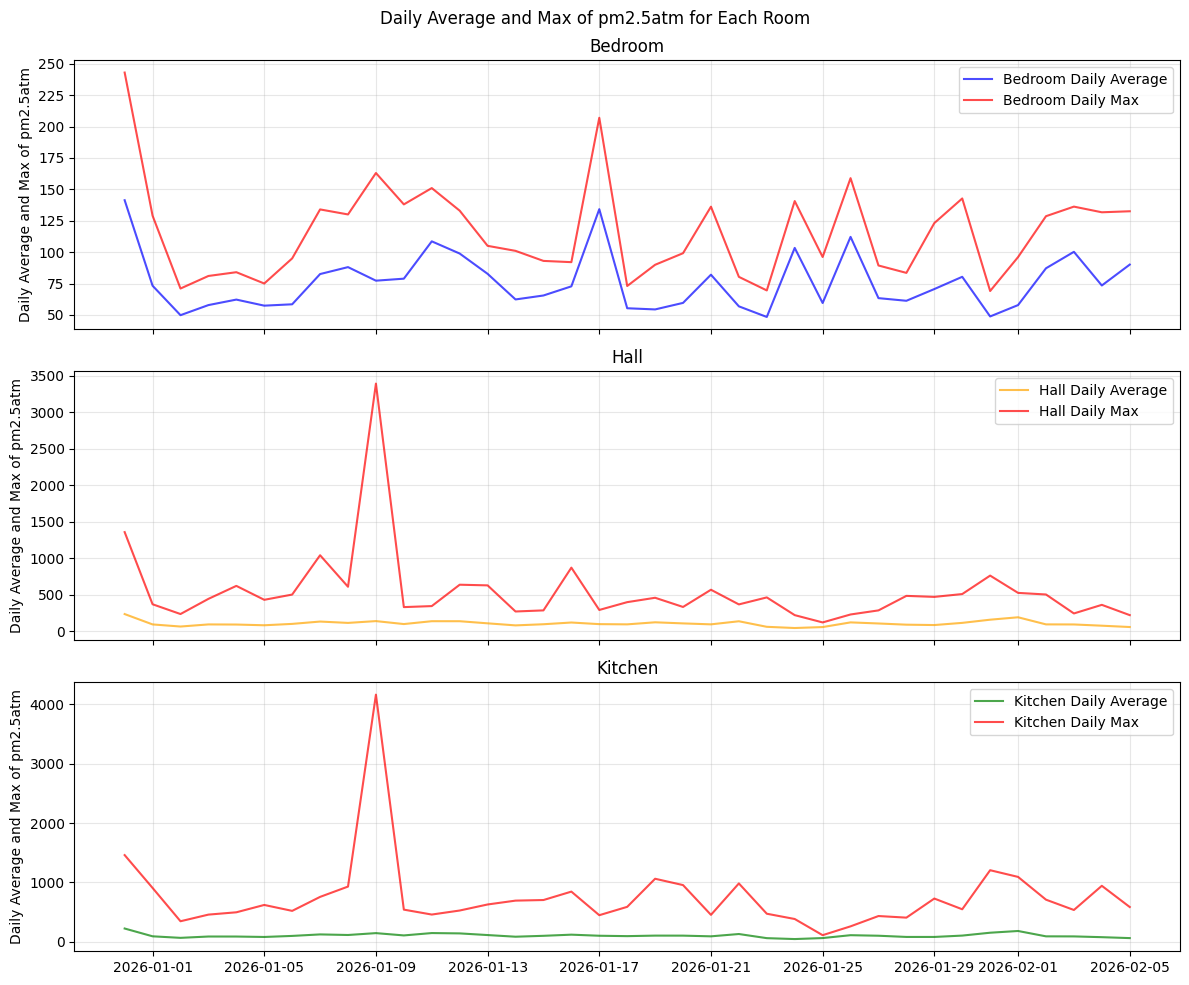

In [8]:
# Call the function
daily_average_trend_plot(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

## Boxplot Across Days (Strong Academic Figure)
- Create box graph per room
  - Per room per day
- This shows:
  - Day-to-day variability
  - Extreme pollution events
  - Consistency of exposure

### Function to plot data

In [9]:
# Alternative version with enhanced statistical information
def create_enhanced_daily_boxplots(hall_data, bedroom_data, kitchen_data, rooms=['Hall', 'Bedroom', 'Kitchen']):
    """
    Enhanced version with additional statistical overlays for academic rigor
    Shows coefficient of variation and identifies high pollution days
    """

    # Remove outliers from the original dataframes before adding the Day field
    bedroom_data = remove_outliers_iqr(bedroom_data, 'pm2.5atm', 200)
    hall_data = remove_outliers_iqr(hall_data, 'pm2.5atm', 1500)
    kitchen_data = remove_outliers_iqr(kitchen_data, 'pm2.5atm', 1500)

    # Add Day field to each dataframe copy
    bedroom_data["Day"] = bedroom_data["DateTime"].dt.day.astype(str)
    hall_data["Day"] = hall_data["DateTime"].dt.day.astype(str)
    kitchen_data["Day"] = kitchen_data["DateTime"].dt.day.astype(str)

    
    # Store the dataframes in a dictionary for easy access
    room_dataframes = {
        'Hall': hall_data,
        'Bedroom': bedroom_data,
        'Kitchen': kitchen_data
    }
    
    fig, axes = plt.subplots(2, len(rooms), figsize=(20, 10), 
                            gridspec_kw={'height_ratios': [3, 1]}, sharey='row')
    if len(rooms) == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, room in enumerate(rooms):
        # Get data for current room from the corresponding dataframe
        room_data = room_dataframes[room]
        
        # Main boxplot (top subplot)
        daily_data = []
        day_labels = []
        daily_stats = []
        
        for day in sorted(room_data['Day'].unique(), key=int):
            day_values = room_data[room_data['Day'] == day]['pm2.5atm'].values
            if len(day_values) > 0:
                daily_data.append(day_values)
                day_labels.append(f'{day}')
                # Calculate daily statistics
                daily_stats.append({
                    'mean': np.mean(day_values),
                    'std': np.std(day_values),
                    'cv': np.std(day_values) / np.mean(day_values) * 100,
                    'max': np.max(day_values)
                })
        
        # Create main boxplot
        bp = axes[0, idx].boxplot(daily_data, tick_labels=day_labels, patch_artist=True)
        
        # Color boxes based on daily mean (gradient from low to high)
        daily_means = [stats['mean'] for stats in daily_stats]
        norm = Normalize(vmin=min(daily_means), vmax=max(daily_means))
        cmap = plt.get_cmap('Reds')
        
        for patch, mean_val in zip(bp['boxes'], daily_means):
            patch.set_facecolor(cmap(norm(mean_val)))
            patch.set_alpha(0.8)
        
        axes[0, idx].set_title(f'{room} - Daily PM2.5 Distribution', fontweight='bold')
        axes[0, idx].set_ylabel('PM2.5 (μg/m³)' if idx == 0 else '')
        axes[0, idx].grid(True, alpha=0.3)
        
        # Bottom subplot: Coefficient of variation to show consistency
        cv_values = [stats['cv'] for stats in daily_stats]
        bars = axes[1, idx].bar(range(len(cv_values)), cv_values, 
                               color='lightblue', alpha=0.7, edgecolor='navy')
        
        # Highlight days with high variability (CV > 50%)
        for i, (bar, cv) in enumerate(zip(bars, cv_values)):
            if cv > 50:  # High variability threshold
                bar.set_color('orange')
                bar.set_alpha(0.9)
        
        axes[1, idx].set_xlabel('Day')
        axes[1, idx].set_ylabel('CV (%)' if idx == 0 else '')
        axes[1, idx].set_title('Daily Variability (Coefficient of Variation)')
        axes[1, idx].set_xticks(range(len(day_labels)))
        axes[1, idx].set_xticklabels(day_labels)
        axes[1, idx].axhline(y=50, color='red', linestyle='--', alpha=0.7, 
                            label='High variability threshold')
        axes[1, idx].grid(True, alpha=0.3)
    
    plt.suptitle('Comprehensive Daily PM2.5 Analysis\n' + 
                'Top: Distribution patterns, Bottom: Variability metrics', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save the plot
    os.makedirs(f'{PLOT_DIR}/Enhanced_Daily_Boxplots', exist_ok=True)
    plt.savefig(f'{PLOT_DIR}/Enhanced_Daily_Boxplots/enhanced_daily_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()

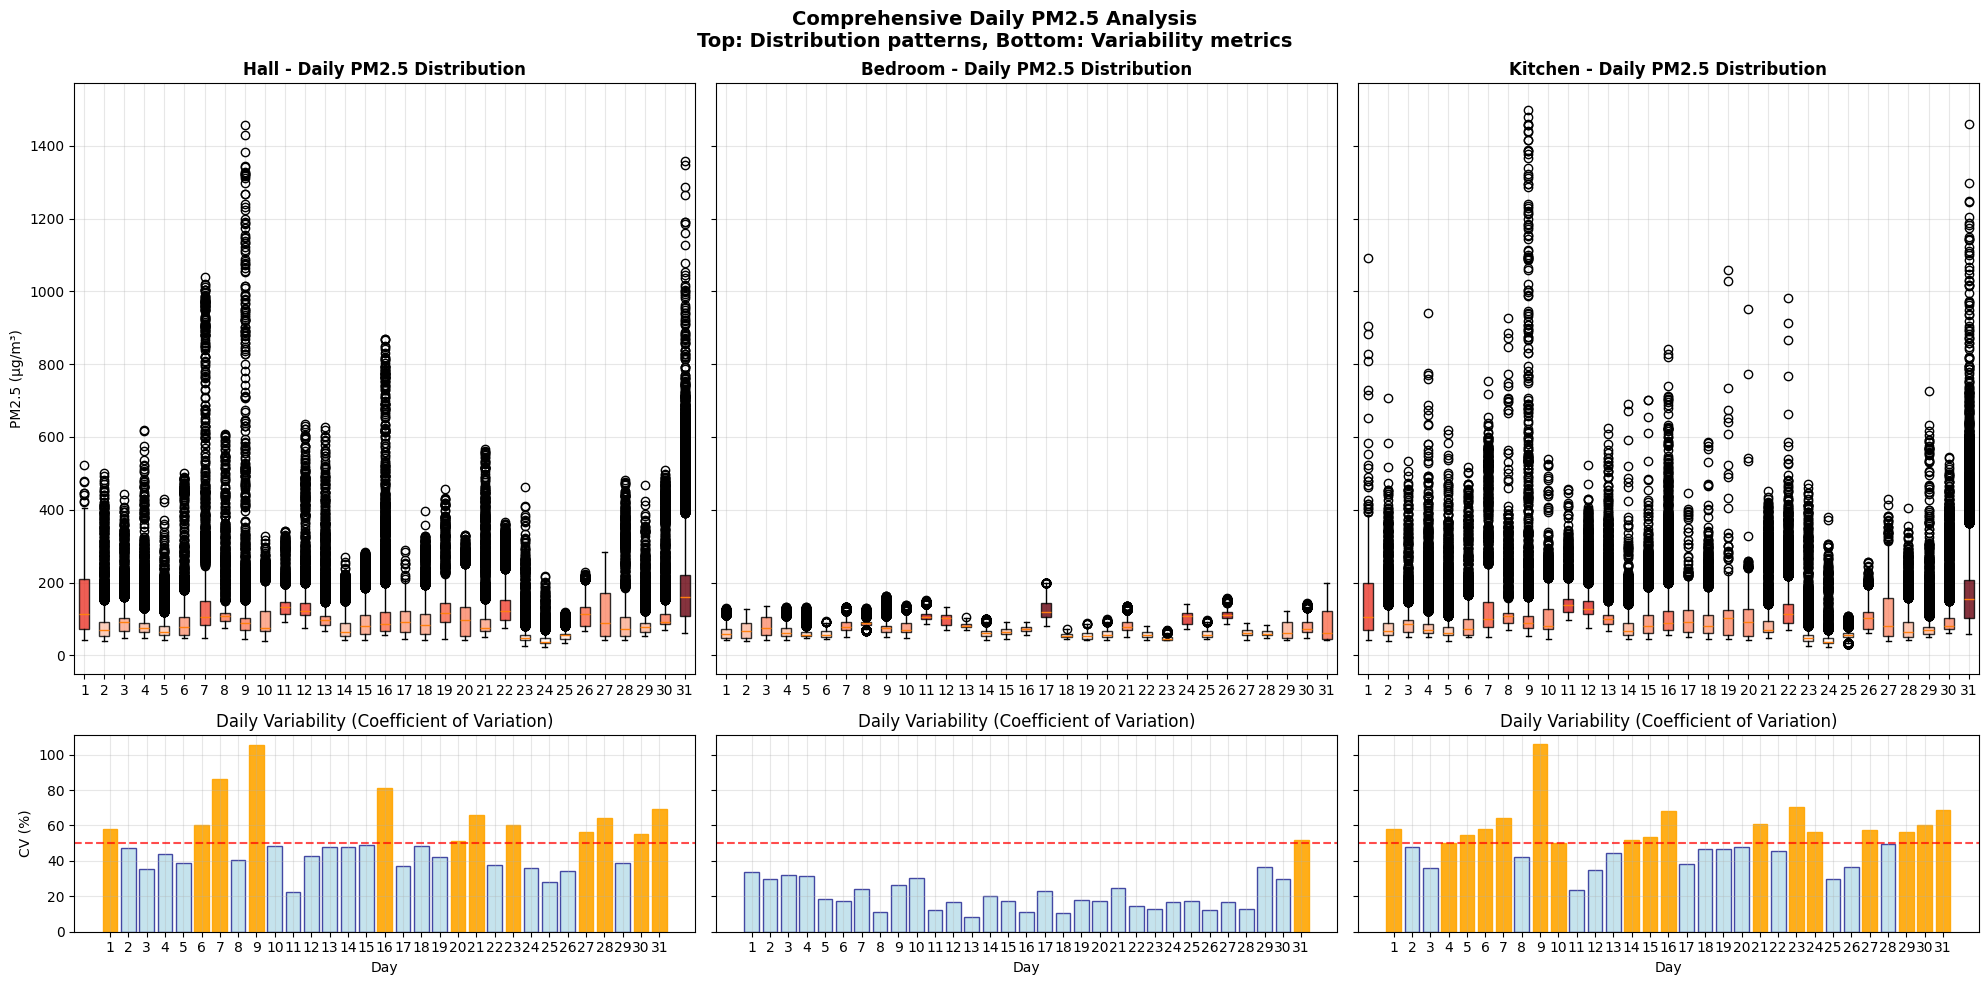

In [10]:
# Create copies of the dataframes to avoid modifying originals
if bedroom_df is None:
    raise ValueError("bedroom_df is None")
bedroom_df_copy = bedroom_df.copy()
if hall_df is None:
    raise ValueError("hall_df is None")
hall_df_copy = hall_df.copy()
if kitchen_df is None:
    raise ValueError("kitchen_df is None")
kitchen_df_copy = kitchen_df.copy()

# Create enhanced daily boxplots for each room
create_enhanced_daily_boxplots(
    hall_data=hall_df_copy, bedroom_data=bedroom_df_copy, kitchen_data=kitchen_df_copy, rooms=['Hall', 'Bedroom', 'Kitchen']
)

## Diurnal Pattern (MOST IMPORTANT FOR SOURCE IDENTIFICATION)
#### Step:
- Extract hour from DateTime
- Compute average PM2.5 for each hour (across all days)

#### Plot:
- Hour (0–23) vs Average PM2.5
- Make separate curves for:
  - Bedroom
  - Hall
  - Kitchen

In [11]:
def diurnal_pattern(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")
    
    # Create a list of only the `DateTime` and `pm2.5atm` columns for each room
    bedroom_hourly_df = bedroom_df[['DateTime', 'pm2.5atm']]
    hall_hourly_df = hall_df[['DateTime', 'pm2.5atm']]
    kitchen_hourly_df = kitchen_df[['DateTime', 'pm2.5atm']]

    # Remove outliers from the original dataframes before adding the Hour field
    bedroom_hourly_df = remove_outliers_iqr(bedroom_hourly_df, 'pm2.5atm', 200)
    hall_hourly_df = remove_outliers_iqr(hall_hourly_df, 'pm2.5atm', 1500)
    kitchen_hourly_df = remove_outliers_iqr(kitchen_hourly_df, 'pm2.5atm', 1500)

    # Create a new column for the hour of the day in each dataframe
    bedroom_hourly_df['Hour'] = bedroom_hourly_df['DateTime'].dt.hour
    hall_hourly_df['Hour'] = hall_hourly_df['DateTime'].dt.hour
    kitchen_hourly_df['Hour'] = kitchen_hourly_df['DateTime'].dt.hour

    # Calculate the average `pm2.5atm` for each hour of the day for each room
    bedroom_hourly_avg = bedroom_hourly_df.groupby('Hour')['pm2.5atm'].mean()
    hall_hourly_avg = hall_hourly_df.groupby('Hour')['pm2.5atm'].mean()
    kitchen_hourly_avg = kitchen_hourly_df.groupby('Hour')['pm2.5atm'].mean()

    # Plot the average `pm2.5atm` for each hour of the day for each room in a subplot with a shared x-axis
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    ax1.plot(bedroom_hourly_avg.index, bedroom_hourly_avg.values, label='Bedroom', color='blue')
    ax1.set_ylabel('Average pm2.5atm')
    ax1.set_title('Average pm2.5atm by Hour of Day - Bedroom')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(hall_hourly_avg.index, hall_hourly_avg.values, label='Hall', color='orange')
    ax2.set_ylabel('Average pm2.5atm')
    ax2.set_title('Average pm2.5atm by Hour of Day - Hall')
    ax2.legend()
    ax2.grid(alpha=0.3)

    ax3.plot(kitchen_hourly_avg.index, kitchen_hourly_avg.values, label='Kitchen', color='green')
    ax3.set_xlabel('Hour of Day')
    ax3.set_ylabel('Average pm2.5atm')
    ax3.set_title('Average pm2.5atm by Hour of Day - Kitchen')
    ax3.legend()
    ax3.grid(alpha=0.3)
    ax3.set_xticks(range(0, 24, 2))
    ax3.set_xticks(range(24), minor=True)
    plt.suptitle('Average pm2.5atm by Hour of Day for Each Room')
    plt.tight_layout()

    # Save the plot
    os.makedirs(f'{PLOT_DIR}/Hourly_Average_Trend_Plot', exist_ok=True)
    plt.savefig(f'{PLOT_DIR}/Hourly_Average_Trend_Plot/pm25_hourly_avg.png', dpi=300, bbox_inches='tight')
    plt.show()

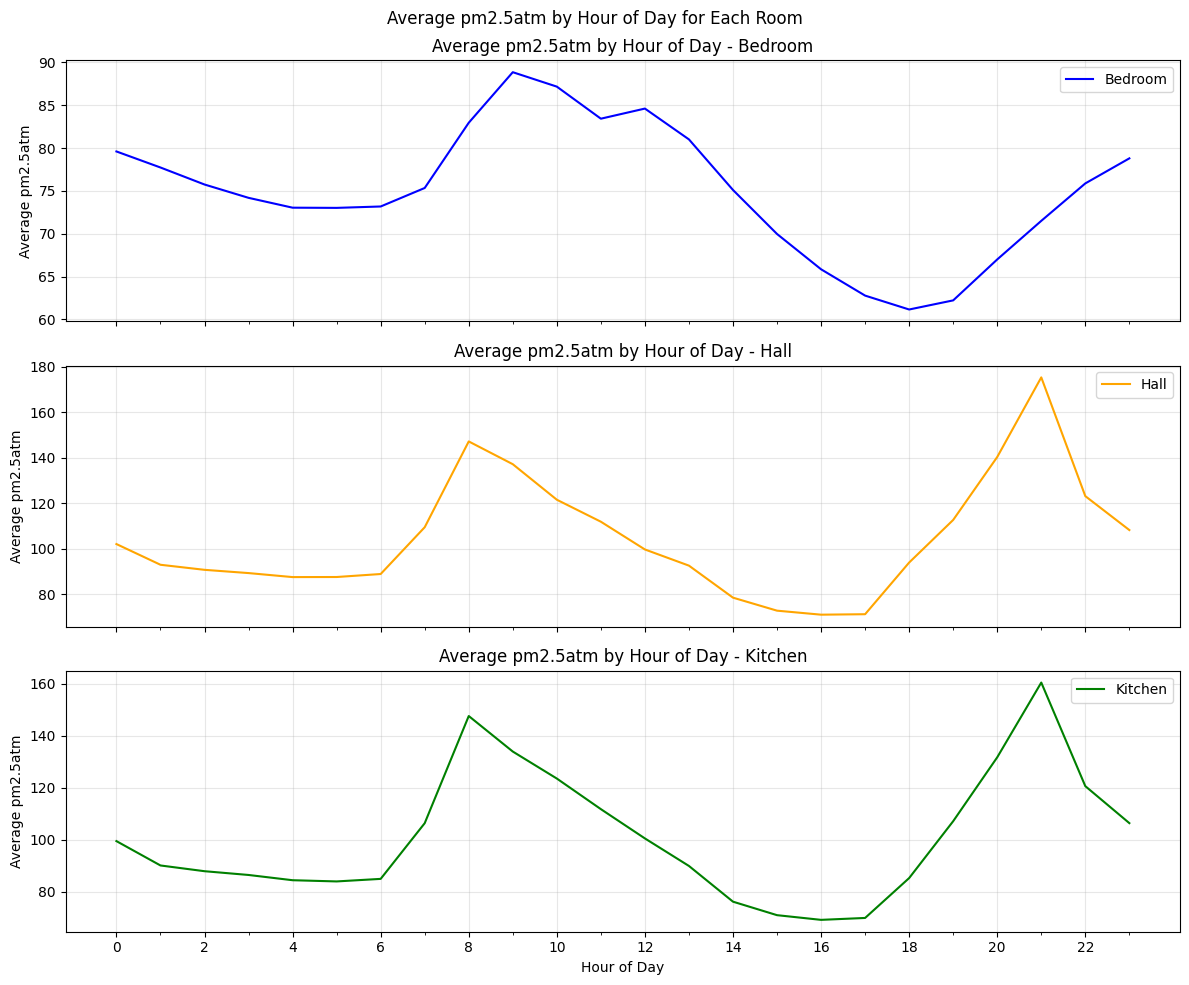

In [12]:
# Call the function
diurnal_pattern(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

## Weekend vs Weekday Comparison (Advanced)
#### Steps
- Add Column `WeekDay` (i.e 1, 2, 3, 4, 5, 6, 7) to all rooms data
- Compute average PM2.5 for:
  - Weekdays (1–5)
  - Weekends (6–7)
#### Plot
- Bar graph comparing average PM2.5 for Weekdays vs Weekends for each room

In [13]:
def weekdays_vs_weekends_comparison(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")

    # Create a list of only the `DateTime` and `pm2.5atm` columns for each room
    bedroom_weekly_df = bedroom_df[['DateTime', 'pm2.5atm']]
    hall_weekly_df = hall_df[['DateTime', 'pm2.5atm']]
    kitchen_weekly_df = kitchen_df[['DateTime', 'pm2.5atm']]

    # Remove outliers from the original dataframes before adding the Week field
    bedroom_weekly_df = remove_outliers_iqr(bedroom_weekly_df, 'pm2.5atm', 200)
    hall_weekly_df = remove_outliers_iqr(hall_weekly_df, 'pm2.5atm', 1500)
    kitchen_weekly_df = remove_outliers_iqr(kitchen_weekly_df, 'pm2.5atm', 1500)

    # Create a new column for the weekday of the year in each dataframe
    bedroom_weekly_df['Weekday'] = bedroom_weekly_df['DateTime'].dt.dayofweek
    hall_weekly_df['Weekday'] = hall_weekly_df['DateTime'].dt.dayofweek
    kitchen_weekly_df['Weekday'] = kitchen_weekly_df['DateTime'].dt.dayofweek

    # Calculate the average `pm2.5atm` for each weekday for each room
    bedroom_weekly_avg = bedroom_weekly_df.groupby('Weekday')['pm2.5atm'].mean()
    hall_weekly_avg = hall_weekly_df.groupby('Weekday')['pm2.5atm'].mean()
    kitchen_weekly_avg = kitchen_weekly_df.groupby('Weekday')['pm2.5atm'].mean()

    # Calculate the average 'pm2.5atm' for weekends (Saturday and Sunday) and weekdays (Monday to Friday) for each room
    bedroom_weekly_avg['Weekend'] = bedroom_weekly_df[bedroom_weekly_df['Weekday'] >= 5]['pm2.5atm'].mean()
    bedroom_weekly_avg['Weekday'] = bedroom_weekly_df[bedroom_weekly_df['Weekday'] < 5]['pm2.5atm'].mean()
    hall_weekly_avg['Weekend'] = hall_weekly_df[hall_weekly_df['Weekday'] >= 5]['pm2.5atm'].mean()
    hall_weekly_avg['Weekday'] = hall_weekly_df[hall_weekly_df['Weekday'] < 5]['pm2.5atm'].mean()
    kitchen_weekly_avg['Weekend'] = kitchen_weekly_df[kitchen_weekly_df['Weekday'] >= 5]['pm2.5atm'].mean()
    kitchen_weekly_avg['Weekday'] = kitchen_weekly_df[kitchen_weekly_df['Weekday'] < 5]['pm2.5atm'].mean()

    # Plot the average `pm2.5atm` for Weekday vs Weekend for each room in a subplot with a shared x-axis
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    ax1.bar(['Weekday', 'Weekend'], [bedroom_weekly_avg['Weekday'], bedroom_weekly_avg['Weekend']], color=['green', 'lightgreen'])
    ax2.bar(['Weekday', 'Weekend'], [hall_weekly_avg['Weekday'], hall_weekly_avg['Weekend']], color=['green', 'lightgreen'])
    ax3.bar(['Weekday', 'Weekend'], [kitchen_weekly_avg['Weekday'], kitchen_weekly_avg['Weekend']], color=['green', 'lightgreen'])
    ax1.set_ylabel('Average pm2.5atm')
    ax1.set_title('Average pm2.5atm - Bedroom')
    ax1.grid(alpha=0.5)
    ax1.set_yticks(np.arange(0, max(bedroom_weekly_avg['Weekday'], bedroom_weekly_avg['Weekend']) + 20, 10))
    ax2.set_ylabel('Average pm2.5atm')
    ax2.set_title('Average pm2.5atm - Hall')
    ax2.grid(alpha=0.5)
    ax2.set_yticks(np.arange(0, max(hall_weekly_avg['Weekday'], hall_weekly_avg['Weekend']) + 20, 10))
    ax3.set_ylabel('Average pm2.5atm')
    ax3.set_title('Average pm2.5atm - Kitchen')
    ax3.grid(alpha=0.5)
    ax3.set_yticks(np.arange(0, max(kitchen_weekly_avg['Weekday'], kitchen_weekly_avg['Weekend']) + 20, 10))
    ax3.set_xlabel('Day Type')
    plt.suptitle('Average pm2.5atm for Weekday vs Weekend for Each Room')
    plt.tight_layout()

    # Save the plot
    os.makedirs(f'{PLOT_DIR}/Weekday_vs_Weekend_Comparison', exist_ok=True)
    plt.savefig(f'{PLOT_DIR}/Weekday_vs_Weekend_Comparison/weekday_weekend_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

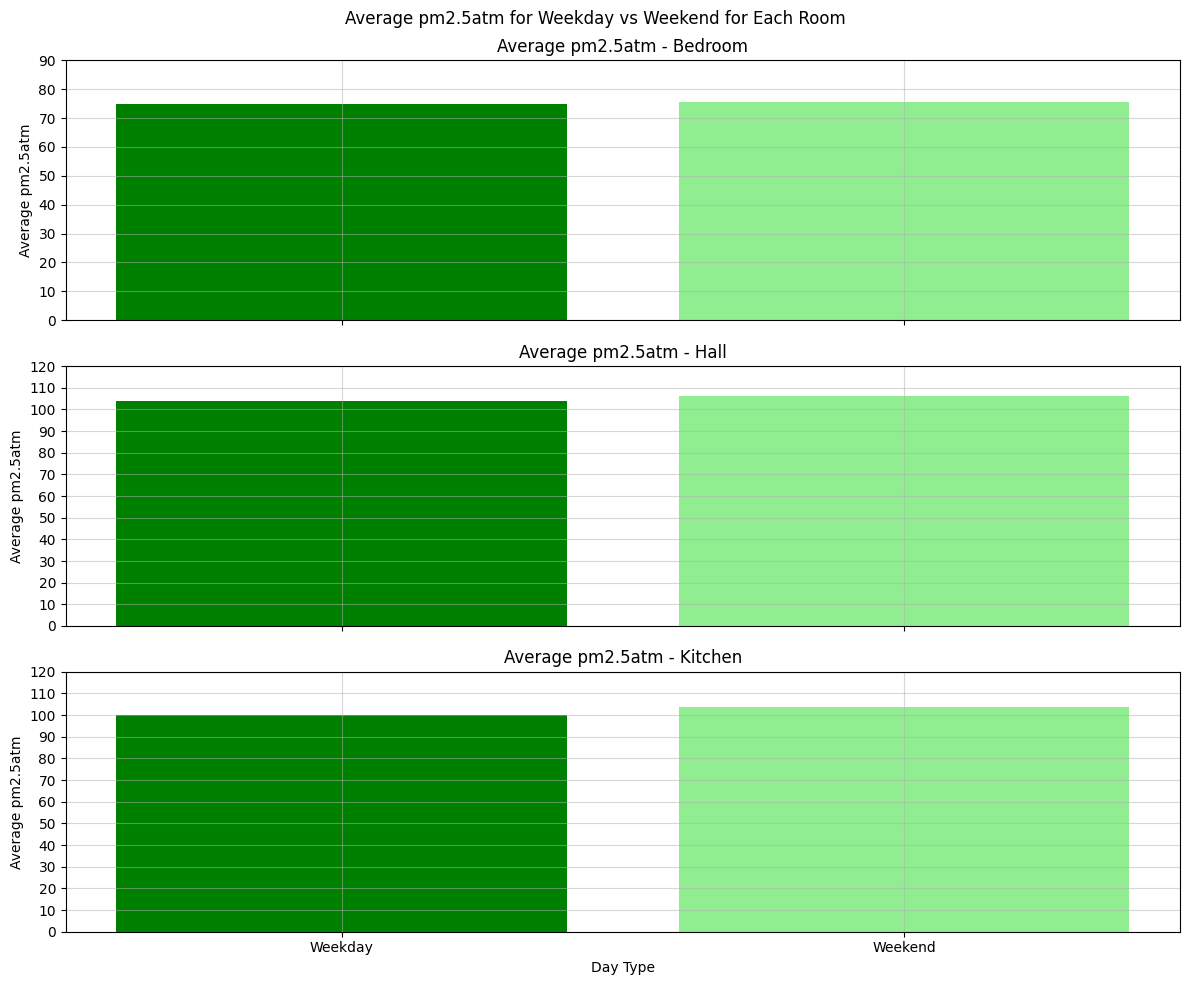

In [14]:
# Call the function
weekdays_vs_weekends_comparison(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

## Percentage Time Above Guidelines (Exposure Burden)
#### Calculate for each room:
- % time `pm2.5atm` > 25 µg/m³ (WHO)
- % time `pm2.5atm` > 60 µg/m³ (India 24-hr NAAQS)
- % change change in `pm2.5atm` from the previous measurement for each room
#### Plot
- print % time `pm2.5atm` > 25 µg/m³ (WHO)
- print% time `pm2.5atm` > 60 µg/m³ (India 24*hr NAAQS)
- line graph showing '% change in `pm2.5atm` from the previous measurement for each room'

In [15]:
def percentage_time_above_guidelines(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")

    # Create a list of only the `DateTime` and `pm2.5atm` columns for each room
    bedroom_percent_df = bedroom_df[['DateTime', 'pm2.5atm']]
    hall_percent_df = hall_df[['DateTime', 'pm2.5atm']]
    kitchen_percent_df = kitchen_df[['DateTime', 'pm2.5atm']]

    # Remove outliers from the original dataframes before adding the Percent Change field
    bedroom_percent_df = remove_outliers_iqr(bedroom_percent_df, 'pm2.5atm', 200)
    hall_percent_df = remove_outliers_iqr(hall_percent_df, 'pm2.5atm', 1500)
    kitchen_percent_df = remove_outliers_iqr(kitchen_percent_df, 'pm2.5atm', 1500)

    # Calculate percentage times `pm2.5atm` exceeds 25 μg/m³ for each room (WHO guideline)
    bedroom_percent_over_25 = (bedroom_percent_df['pm2.5atm'] > 25).sum() / len(bedroom_percent_df) * 100
    hall_percent_over_25 = (hall_percent_df['pm2.5atm'] > 25).sum() / len(hall_percent_df) * 100
    kitchen_percent_over_25 = (kitchen_percent_df['pm2.5atm'] > 25).sum() / len(kitchen_percent_df) * 100
    print(f"Percentage of time pm2.5atm exceeds 25 μg/m³ - Bedroom: {bedroom_percent_over_25:.2f}%")
    print(f"Percentage of time pm2.5atm exceeds 25 μg/m³ - Hall: {hall_percent_over_25:.2f}%")
    print(f"Percentage of time pm2.5atm exceeds 25 μg/m³ - Kitchen: {kitchen_percent_over_25:.2f}%")

    # Calculate percentage times `pm2.5atm` exceeds 60 μg/m³ for each room (India 24-hr NAAQS guideline)
    bedroom_percent_over_60 = (bedroom_percent_df['pm2.5atm'] > 60).sum() / len(bedroom_percent_df) * 100
    hall_percent_over_60 = (hall_percent_df['pm2.5atm'] > 60).sum() / len(hall_percent_df) * 100
    kitchen_percent_over_60 = (kitchen_percent_df['pm2.5atm'] > 60).sum() / len(kitchen_percent_df) * 100
    print(f"Percentage of time pm2.5atm exceeds 60 μg/m³ - Bedroom: {bedroom_percent_over_60:.2f}%")
    print(f"Percentage of time pm2.5atm exceeds 60 μg/m³ - Hall: {hall_percent_over_60:.2f}%")
    print(f"Percentage of time pm2.5atm exceeds 60 μg/m³ - Kitchen: {kitchen_percent_over_60:.2f}%")

    # Create a new column for the percent change in `pm2.5atm` from the previous measurement for each room
    bedroom_percent_df['Percent Change'] = bedroom_percent_df['pm2.5atm'].pct_change() * 100
    hall_percent_df['Percent Change'] = hall_percent_df['pm2.5atm'].pct_change() * 100
    kitchen_percent_df['Percent Change'] = kitchen_percent_df['pm2.5atm'].pct_change() * 100

    # Plot the percent change in `pm2.5atm` for each room in a subplot with a shared x-axis
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
    ax1.plot(bedroom_percent_df['DateTime'], bedroom_percent_df['Percent Change'], label='Bedroom', color='blue')
    ax1.set_ylabel('Percent Change in pm2.5atm')
    ax1.set_title('Percent Change in pm2.5atm - Bedroom')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(hall_percent_df['DateTime'], hall_percent_df['Percent Change'], label='Hall', color='orange')
    ax2.set_ylabel('Percent Change in pm2.5atm')
    ax2.set_title('Percent Change in pm2.5atm - Hall')
    ax2.legend()
    ax2.grid(alpha=0.3)

    ax3.plot(kitchen_percent_df['DateTime'], kitchen_percent_df['Percent Change'], label='Kitchen', color='green')
    ax3.set_xlabel('DateTime')
    ax3.set_ylabel('Percent Change in pm2.5atm')
    ax3.set_title('Percent Change in pm2.5atm - Kitchen')
    ax3.legend()
    ax3.grid(alpha=0.3)
    plt.suptitle('Percent Change in pm2.5atm for Each Room')

    # Save the plot
    os.makedirs(f'{PLOT_DIR}/Percent_Change_Trend_Plot', exist_ok=True)
    plt.savefig(f'{PLOT_DIR}/Percent_Change_Trend_Plot/percent_change_trend.png', dpi=300, bbox_inches='tight')
    plt.show()

Percentage of time pm2.5atm exceeds 25 μg/m³ - Bedroom: 100.00%
Percentage of time pm2.5atm exceeds 25 μg/m³ - Hall: 99.99%
Percentage of time pm2.5atm exceeds 25 μg/m³ - Kitchen: 99.96%
Percentage of time pm2.5atm exceeds 60 μg/m³ - Bedroom: 63.86%
Percentage of time pm2.5atm exceeds 60 μg/m³ - Hall: 77.64%
Percentage of time pm2.5atm exceeds 60 μg/m³ - Kitchen: 76.11%


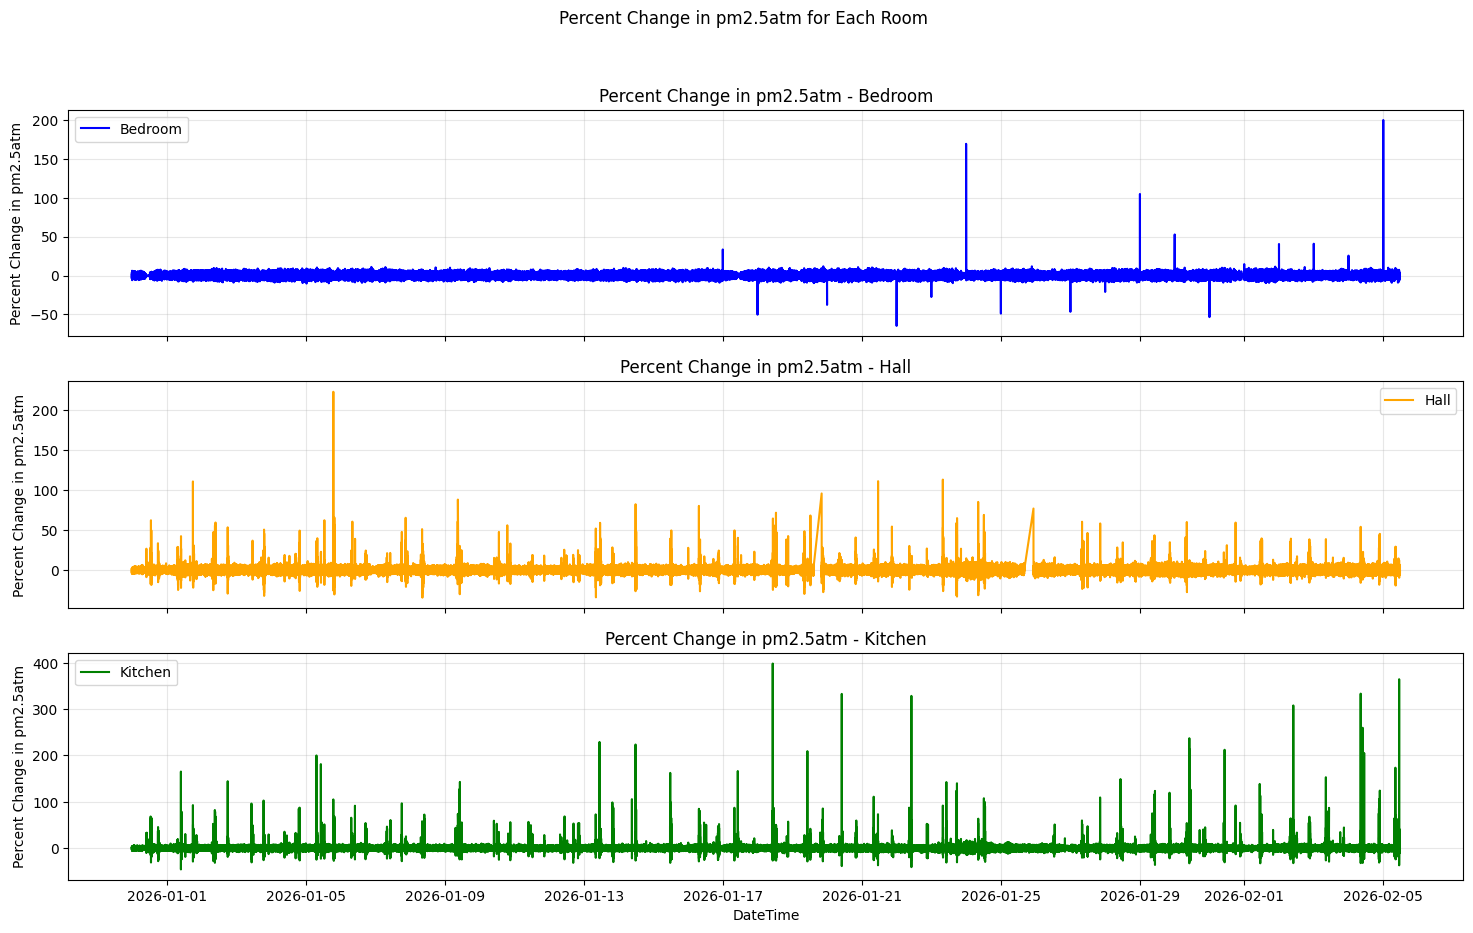

In [16]:
# Call the function
percentage_time_above_guidelines(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

## Peak Event Analysis
#### Define peak event thresholds
- Kitchen & Hall > 300 µg/m³
- Bedroom > 150 µg/m³
#### Calculations:
- For each day calculate:
  - Number of peaks
  - Duration of peaks
  - Maximum peak concentration
  - Note for each rooms

In [17]:
def peak_event_analysis(kitchen_df=None, hall_df=None, bedroom_df=None, kitchen_peak_threshold=300, hall_peak_threshold=300, bedroom_peak_threshold=150):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")

    # Create a list of only the `DateTime` and `pm2.5atm` columns for each room
    bedroom_peak_df = bedroom_df[["DateTime", "pm2.5atm"]]
    hall_peak_df = hall_df[["DateTime", "pm2.5atm"]]
    kitchen_peak_df = kitchen_df[["DateTime", "pm2.5atm"]]

    # Remove outliers from the original dataframes before adding the Peak Event field
    bedroom_peak_df = remove_outliers_iqr(bedroom_peak_df, "pm2.5atm", 200)
    hall_peak_df = remove_outliers_iqr(hall_peak_df, "pm2.5atm", 1500)
    kitchen_peak_df = remove_outliers_iqr(kitchen_peak_df, "pm2.5atm", 1500)

    # Add a new coloum 'Day' to each dataframe to identify the day as "%Y-%M-%d"
    bedroom_peak_df["Day"] = bedroom_peak_df["DateTime"].dt.strftime("%Y-%m-%d")
    hall_peak_df["Day"] = hall_peak_df["DateTime"].dt.strftime("%Y-%m-%d")
    kitchen_peak_df["Day"] = kitchen_peak_df["DateTime"].dt.strftime("%Y-%m-%d")

    # Create a new column to identify peak events for each room
    bedroom_peak_df["Peak Event"] = bedroom_peak_df["pm2.5atm"] > bedroom_peak_threshold
    hall_peak_df["Peak Event"] = hall_peak_df["pm2.5atm"] > hall_peak_threshold
    kitchen_peak_df["Peak Event"] = kitchen_peak_df["pm2.5atm"] > kitchen_peak_threshold

    # Ensure that data frames are sorted by DateTime
    bedroom_peak_df.sort_values(by="DateTime", inplace=True)
    hall_peak_df.sort_values(by="DateTime", inplace=True)
    kitchen_peak_df.sort_values(by="DateTime", inplace=True)

    # Identify Peack Start
    bedroom_peak_df["Peak Start"] = (bedroom_peak_df["Peak Event"] == True) & (bedroom_peak_df["Peak Event"].shift(1) == False)
    hall_peak_df["Peak Start"] = (hall_peak_df["Peak Event"] == True) & (hall_peak_df["Peak Event"].shift(1) == False)
    kitchen_peak_df["Peak Start"] = (kitchen_peak_df["Peak Event"] == True) & (kitchen_peak_df["Peak Event"].shift(1) == False)

    # Assign a unique ID to each peak event
    bedroom_peak_df["Peak ID"] = bedroom_peak_df["Peak Start"].cumsum()
    hall_peak_df["Peak ID"] = hall_peak_df["Peak Start"].cumsum()
    kitchen_peak_df["Peak ID"] = kitchen_peak_df["Peak Start"].cumsum()

    # All days in the dataset for each room to ensure we keep days with no peak events in the analysis
    all_days = pd.date_range(start=bedroom_peak_df["Day"].min(), end=bedroom_peak_df["Day"].max()).strftime("%Y-%m-%d")

    # Remove non peak events
    bedroom_peak_df = bedroom_peak_df[bedroom_peak_df["Peak Event"] == True]
    hall_peak_df = hall_peak_df[hall_peak_df["Peak Event"] == True]
    kitchen_peak_df = kitchen_peak_df[kitchen_peak_df["Peak Event"] == True]

    # Count number of peak events per day for each room
    bedroom_peak_events_per_day = bedroom_peak_df.groupby("Day")["Peak ID"].nunique().reset_index(name="Peak Events")
    hall_peak_events_per_day = hall_peak_df.groupby("Day")["Peak ID"].nunique().reset_index(name="Peak Events")
    kitchen_peak_events_per_day = kitchen_peak_df.groupby("Day")["Peak ID"].nunique().reset_index(name="Peak Events")
    # Keep days with no peak events as well
    bedroom_peak_events_per_day = bedroom_peak_events_per_day.set_index("Day").reindex(all_days, fill_value=0).reset_index()
    hall_peak_events_per_day = hall_peak_events_per_day.set_index("Day").reindex(all_days, fill_value=0).reset_index()
    kitchen_peak_events_per_day = kitchen_peak_events_per_day.set_index("Day").reindex(all_days, fill_value=0).reset_index()

    # Calculate Duration of Each Peak Event with Day
    bedroom_peak_duration = bedroom_peak_df.groupby(["Day", "Peak ID"])["DateTime"].agg(["min", "max"]).reset_index()
    hall_peak_duration = hall_peak_df.groupby(["Day", "Peak ID"])["DateTime"].agg(["min", "max"]).reset_index()
    kitchen_peak_duration = kitchen_peak_df.groupby(["Day", "Peak ID"])["DateTime"].agg(["min", "max"]).reset_index()
    bedroom_peak_duration["Duration (minutes)"] = (bedroom_peak_duration["max"] - bedroom_peak_duration["min"]).dt.total_seconds() / 60
    hall_peak_duration["Duration (minutes)"] = (hall_peak_duration["max"] - hall_peak_duration["min"]).dt.total_seconds() / 60
    kitchen_peak_duration["Duration (minutes)"] = (kitchen_peak_duration["max"] - kitchen_peak_duration["min"]).dt.total_seconds() / 60
    # Replace 0.0 with 1/60 to avoid zero duration
    bedroom_peak_duration["Duration (minutes)"] = bedroom_peak_duration["Duration (minutes)"].replace(0.0, 1/60)
    hall_peak_duration["Duration (minutes)"] = hall_peak_duration["Duration (minutes)"].replace(0.0, 1/60)
    kitchen_peak_duration["Duration (minutes)"] = kitchen_peak_duration["Duration (minutes)"].replace(0.0, 1/60)

    # Maximum Peak Concentration Per Day
    bedroom_peak_max = bedroom_peak_df.groupby("Day")["pm2.5atm"].max().reset_index(name="Max pm2.5atm")
    hall_peak_max = hall_peak_df.groupby("Day")["pm2.5atm"].max().reset_index(name="Max pm2.5atm")
    kitchen_peak_max = kitchen_peak_df.groupby("Day")["pm2.5atm"].max().reset_index(name="Max pm2.5atm")

    # Save the peak event analysis results to CSV files
    os.makedirs(f'{PLOT_DIR}/Peak_Event_Analysis', exist_ok=True)

    # Number of peak events per day for each room
    bedroom_peak_events_per_day.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/bedroom_peak_events_per_day.csv', index=False)
    hall_peak_events_per_day.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/hall_peak_events_per_day.csv', index=False)
    kitchen_peak_events_per_day.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/kitchen_peak_events_per_day.csv', index=False)

    # Duration of each peak event for each room
    bedroom_peak_duration.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/bedroom_peak_duration.csv', index=False)
    hall_peak_duration.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/hall_peak_duration.csv', index=False)
    kitchen_peak_duration.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/kitchen_peak_duration.csv', index=False)

    # Maximum peak concentration per day for each room
    bedroom_peak_max.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/bedroom_peak_max.csv', index=False)
    hall_peak_max.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/hall_peak_max.csv', index=False)
    kitchen_peak_max.to_csv(f'{PLOT_DIR}/Peak_Event_Analysis/kitchen_peak_max.csv', index=False)

    # For each room print total number of peak events, average duration of peak events, max duration of peak events, and average maximum concentration, max maximum concentration during peak events
    # Bedroom
    print(f"Total number of peak events - Bedroom: {bedroom_peak_df['Peak ID'].nunique()}")
    print(f"Average duration of peak events (minutes) - Bedroom: {bedroom_peak_duration['Duration (minutes)'].mean():.2f}")
    print(f"Max duration of peak events (minutes) - Bedroom: {bedroom_peak_duration['Duration (minutes)'].max():.2f}")
    print(f"Average maximum concentration during peak events (µg/m³) - Bedroom: {bedroom_peak_max['Max pm2.5atm'].mean():.2f}")
    print(f"Max maximum concentration during peak events (µg/m³) - Bedroom: {bedroom_peak_max['Max pm2.5atm'].max():.2f}")
    # Hall
    print(f"\nTotal number of peak events - Hall: {hall_peak_df['Peak ID'].nunique()}")
    print(f"Average duration of peak events (minutes) - Hall: {hall_peak_duration['Duration (minutes)'].mean():.2f}")
    print(f"Max duration of peak events (minutes) - Hall: {hall_peak_duration['Duration (minutes)'].max():.2f}")
    print(f"Average maximum concentration during peak events (µg/m³) - Hall: {hall_peak_max['Max pm2.5atm'].mean():.2f}")
    print(f"Max maximum concentration during peak events (µg/m³) - Hall: {hall_peak_max['Max pm2.5atm'].max():.2f}")
    # Kitchen
    print(f"\nTotal number of peak events - Kitchen: {kitchen_peak_df['Peak ID'].nunique()}")
    print(f"Average duration of peak events (minutes) - Kitchen: {kitchen_peak_duration['Duration (minutes)'].mean():.2f}")
    print(f"Max duration of peak events (minutes) - Kitchen: {kitchen_peak_duration['Duration (minutes)'].max():.2f}")
    print(f"Average maximum concentration during peak events (µg/m³) - Kitchen: {kitchen_peak_max['Max pm2.5atm'].mean():.2f}")
    print(f"Max maximum concentration during peak events (µg/m³) - Kitchen: {kitchen_peak_max['Max pm2.5atm'].max():.2f}")

In [18]:
# Call the function
peak_event_analysis(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

Total number of peak events - Bedroom: 148
Average duration of peak events (minutes) - Bedroom: 5.83
Max duration of peak events (minutes) - Bedroom: 408.83
Average maximum concentration during peak events (µg/m³) - Bedroom: 174.57
Max maximum concentration during peak events (µg/m³) - Bedroom: 200.00

Total number of peak events - Hall: 210
Average duration of peak events (minutes) - Hall: 4.59
Max duration of peak events (minutes) - Hall: 244.83
Average maximum concentration during peak events (µg/m³) - Hall: 585.74
Max maximum concentration during peak events (µg/m³) - Hall: 1458.00

Total number of peak events - Kitchen: 360
Average duration of peak events (minutes) - Kitchen: 2.33
Max duration of peak events (minutes) - Kitchen: 242.85
Average maximum concentration during peak events (µg/m³) - Kitchen: 709.83
Max maximum concentration during peak events (µg/m³) - Kitchen: 1498.00


## Cooking-Related PM2.5 Contribution Analysis
#### Define cooking windows (This are general and most prefered not always correct)
- Morning + Afternoon : 6:00 to 12:00 (From morning tea to Lunch)
- Evening : 17:00 to 22:00 (From evening tea to Dinner)
#### Steps
- Crate a dataframe with `DateTime` and `pm2.5atm` as coloums
- Add coloums `hour`, `minute`, `time`
- Add coloums `Period` which classifies each entry as `Morning Cooking + Lunch`, `Evening Cooking + Dinner`, and `Non-Cooking`
- Compare `Mean`, `Max`, `Standard Deviation` of `pm2.5atm` by Period
- Compare Peak Frequency by Period
- Exposure Contribution Analysis
  - Calculate Total `pm2.5atm` during cooking vs total daily `pm2.5atm`
  - Then compute percentage
- Plot Diurnal Curve With Shaded Cooking Windows
  - Plot hourly average `pm2.5atm`
  - Then highlight Cooking durations
- Room-Wise Cooking Impact
  - Repeat analysis separately for:
    - Kitchen
    - Hall
    - Bedroom

### Helper Function

In [19]:
from datetime import time


def classify_period(t):
    """
    Morning + Afternoon : 6:00 to 12:00 (From morning tea to Lunch)
    Evening : 17:00 to 22:00 (From evening tea to Dinner)
    """
    if time(6, 0) <= t <= time(12, 0):
        return "Morning Cooking + Lunch"
    elif time(17, 0) <= t <= time(22, 0):
        return "Evening Cooking + Dinner"
    else:
        return "Non-Cooking"


def get_total_hours(period):
    if period == "Morning Cooking + Lunch":
        return 6  # 6-12
    elif period == "Evening Cooking + Dinner":
        return 5  # 17-22
    else:
        return 13 # remaining hours


def calculate_cooking_related_PM2_5_contribution_analysis(
    room_df, room_name, peak_threshold, outliaer_threshold
):
    room_df = room_df[["DateTime", "pm2.5atm"]].copy()
    room_df = remove_outliers_iqr(room_df, "pm2.5atm", outliaer_threshold)
    room_df["Day"] = room_df["DateTime"].dt.strftime("%Y-%m-%d")
    room_df["Hour"] = room_df["DateTime"].dt.hour
    room_df["Minute"] = room_df["DateTime"].dt.minute
    room_df["Time"] = room_df["DateTime"].dt.time

    room_df["Period"] = room_df["Time"].apply(classify_period)
    room_df["Peak Event"] = room_df["pm2.5atm"] > peak_threshold

    # Compare `Mean`, `Max`, `Standard Deviation` of `pm2.5atm` by Period
    period_stats = (
        room_df.groupby("Period")["pm2.5atm"].agg(["mean", "max", "std"]).reset_index()
    )
    print(f"\nPM2.5 Contribution Analysis for {room_name}:")
    print(period_stats)

    # Compare peak frequency by Period
    peak_frequency = (
        room_df.groupby("Period")["Peak Event"].sum().reset_index(name="Peak Frequency")
    )
    print(f"\nPeak Frequency by Period for {room_name}:")
    print(peak_frequency)

    # Exposure contribution by Period (sum of pm2.5atm during peak events in each period)
    exposure_contribution_by_period = (
        room_df.groupby("Period")["pm2.5atm"]
        .sum()
        .reset_index(name="Exposure Contribution")
    )
    exposure_total = exposure_contribution_by_period["Exposure Contribution"].sum()
    exposure_contribution_by_period["Exposure Contribution (%)"] = (
        exposure_contribution_by_period["Exposure Contribution"] / exposure_total
    ) * 100
    
    exposure_contribution_by_period["Exposure Contribution (%) per hour"] = (
        exposure_contribution_by_period["Exposure Contribution (%)"]
        / get_total_hours(exposure_contribution_by_period["Period"].values[0])
    )
    print(f"\nExposure Contribution by Period for {room_name}:")
    print(exposure_contribution_by_period)

    # Plot Diurnal Curve With Shaded Cooking Windows
    # Plot hourly average `pm2.5atm`
    # Then highlight Cooking durations
    hourly_avg = room_df.groupby("Hour")["pm2.5atm"].mean().reset_index()
    plt.figure(figsize=(12, 6))
    plt.plot(
        hourly_avg["Hour"],
        hourly_avg["pm2.5atm"],
        marker="o",
        label="Hourly Average pm2.5atm",
    )
    plt.axvspan(
        6, 12, color="orange", alpha=0.3, label="Morning Cooking + Lunch Window"
    )
    plt.axvspan(
        17, 22, color="orange", alpha=0.3, label="Evening Cooking + Dinner Window"
    )
    plt.title(f"Diurnal Variation of pm2.5atm with Cooking Windows - {room_name}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average pm2.5atm (µg/m³)")
    plt.xticks(range(0, 24))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    # Save the plot
    os.makedirs("data/Dhruv_Patel/Plots/Cooking_Contribution_Analysis", exist_ok=True)
    plt.savefig(
        f"data/Dhruv_Patel/Plots/Cooking_Contribution_Analysis/{room_name.lower()}_cooking_contribution.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


PM2.5 Contribution Analysis for Bedroom:
                     Period       mean    max        std
0  Evening Cooking + Dinner  64.936559  125.0  20.173313
1   Morning Cooking + Lunch  81.737394  200.0  29.621798
2               Non-Cooking  75.722769  200.0  25.667451

Peak Frequency by Period for Bedroom:
                     Period  Peak Frequency
0  Evening Cooking + Dinner               0
1   Morning Cooking + Lunch            2067
2               Non-Cooking            1147

Exposure Contribution by Period for Bedroom:
                     Period  Exposure Contribution  Exposure Contribution (%)  \
0  Evening Cooking + Dinner             3822620.44                  18.100126   
1   Morning Cooking + Lunch             5686715.68                  26.926626   
2               Non-Cooking            11609966.36                  54.973247   

   Exposure Contribution (%) per hour  
0                            3.620025  
1                            5.385325  
2                       

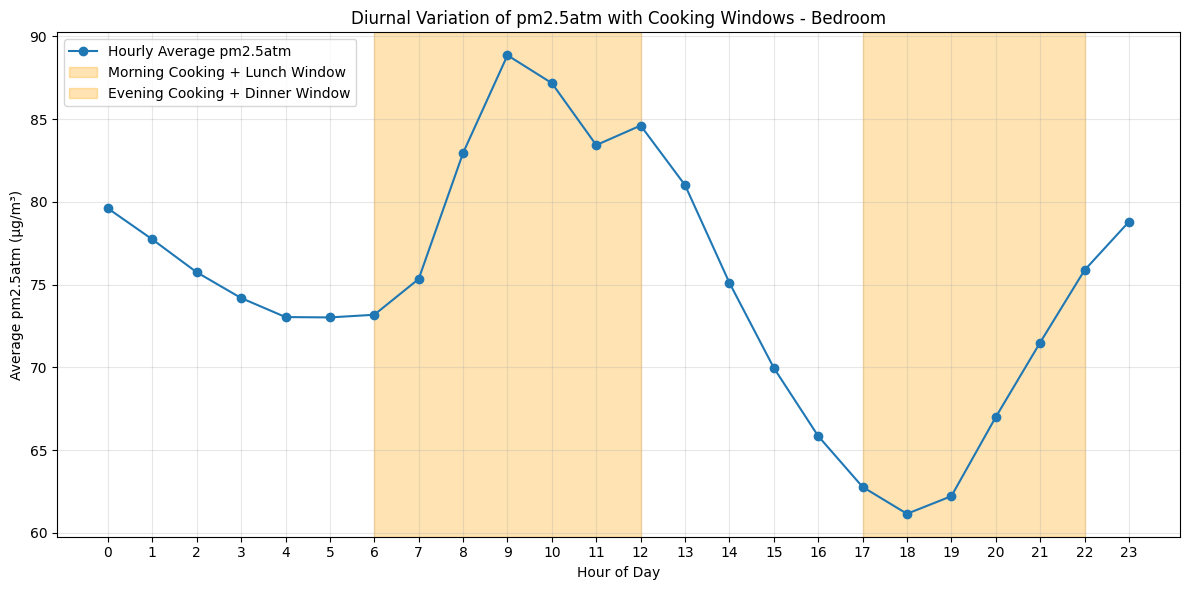


PM2.5 Contribution Analysis for Hall:
                     Period        mean     max        std
0  Evening Cooking + Dinner  119.184806  1040.0  94.635907
1   Morning Cooking + Lunch  119.394740  1458.0  76.620732
2               Non-Cooking   92.198989  1357.0  52.546189

Peak Frequency by Period for Hall:
                     Period  Peak Frequency
0  Evening Cooking + Dinner            2432
1   Morning Cooking + Lunch            2351
2               Non-Cooking             576

Exposure Contribution by Period for Hall:
                     Period  Exposure Contribution  Exposure Contribution (%)  \
0  Evening Cooking + Dinner              6683288.0                  22.657349   
1   Morning Cooking + Lunch              8643224.0                  29.301826   
2               Non-Cooking             14170708.0                  48.040826   

   Exposure Contribution (%) per hour  
0                            4.531470  
1                            5.860365  
2                        

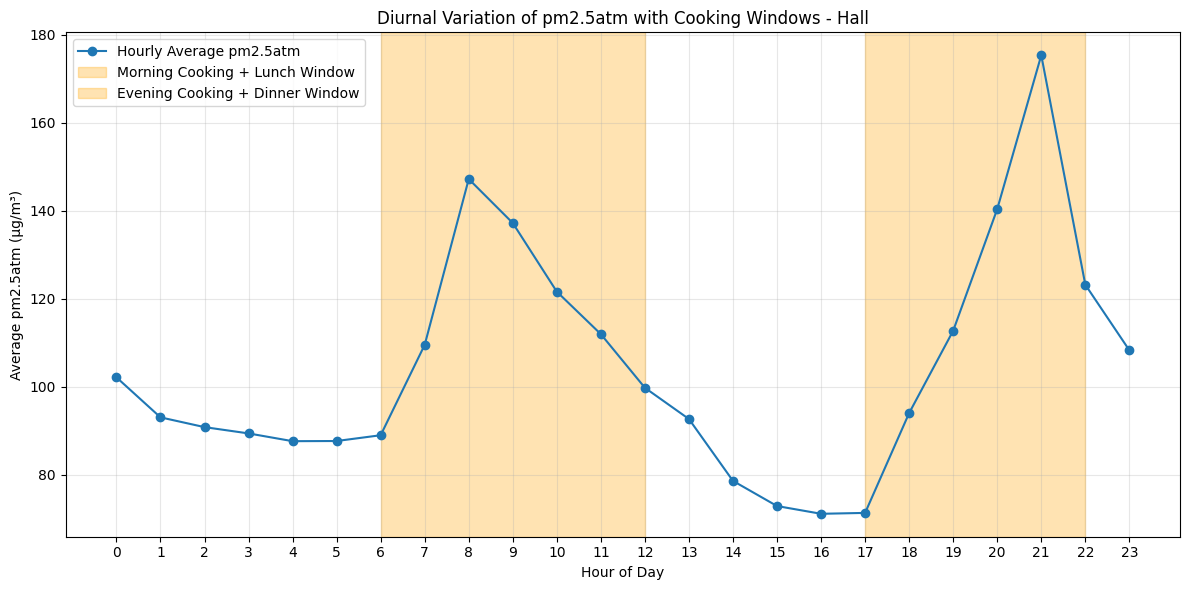


PM2.5 Contribution Analysis for Kitchen:
                     Period        mean     max        std
0  Evening Cooking + Dinner  110.840290  1204.0  77.573813
1   Morning Cooking + Lunch  117.969905  1498.0  81.289594
2               Non-Cooking   89.663966  1459.0  50.062071

Peak Frequency by Period for Kitchen:
                     Period  Peak Frequency
0  Evening Cooking + Dinner            1824
1   Morning Cooking + Lunch            2502
2               Non-Cooking             486

Exposure Contribution by Period for Kitchen:
                     Period  Exposure Contribution  Exposure Contribution (%)  \
0  Evening Cooking + Dinner              6518850.0                  22.516064   
1   Morning Cooking + Lunch              8533707.0                  29.475367   
2               Non-Cooking             13899439.0                  48.008569   

   Exposure Contribution (%) per hour  
0                            4.503213  
1                            5.895073  
2               

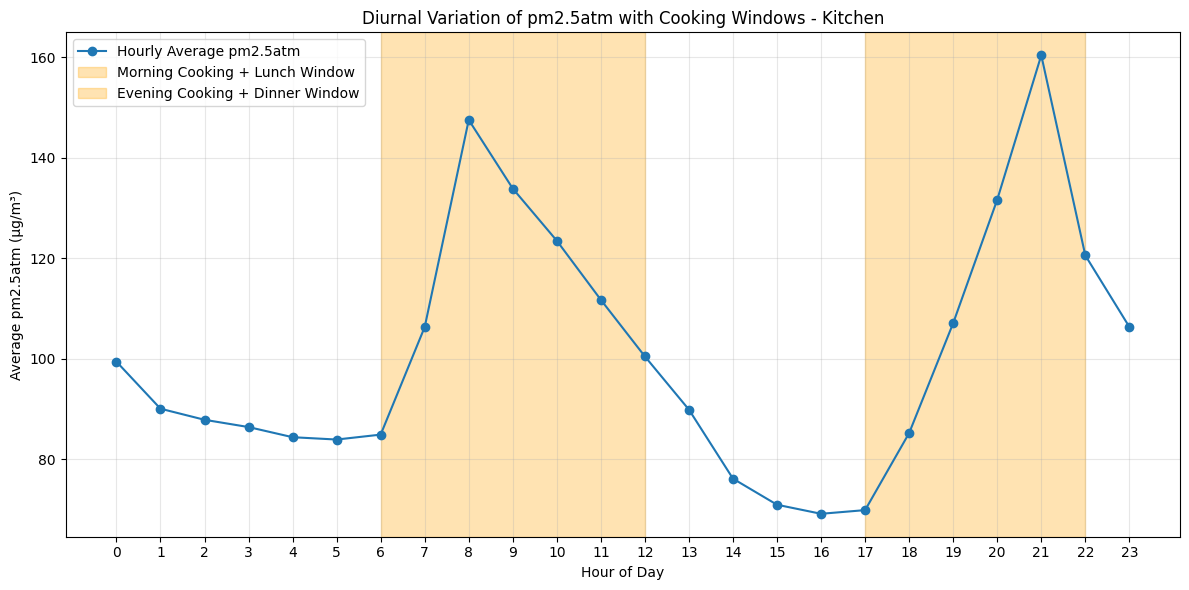

In [20]:
# Analyze cooking related PM2.5 contribution for each room
calculate_cooking_related_PM2_5_contribution_analysis(bedroom_df, "Bedroom", 150, 200)
calculate_cooking_related_PM2_5_contribution_analysis(hall_df, "Hall", 300, 1500)
calculate_cooking_related_PM2_5_contribution_analysis(kitchen_df, "Kitchen", 300, 1500)

## Decay Rate After Cooking (Ventilation Efficiency Proxy)
- For each major spike Measure time taken for PM2.5 to return to baseline
- We analyze:
  - How long it takes to return to baseline
  - How fast concentration decreases
#### Steps:
- For Each Cooking period, Identify Decay Start
  - The time of maximum concentration within that period.
- Define Baseline
  - Average non-cooking period concentration
- Calculate Decay Duration
  - Start at period maximum concentration time
  - Find first time when PM2.5 returns near baseline
#### Plot:
- Select one representative period (One with maximum duration or maximum concentration)
- Plot concentration vs time for this period
- Highlight:
  - Peak maximum
  - Recovery point
  - Decay slope

### Helper Function

In [21]:
from datetime import time


def classify_period_simple(t):
    """
    Morning + Afternoon : 6:00 to 12:00 (From morning tea to Lunch)
    Evening : 17:00 to 22:00 (From evening tea to Dinner)
    Both classified as `Cooking`
    """
    if time(6, 0) <= t <= time(12, 0) or time(17, 0) <= t <= time(22, 0):
        return "Cooking"
    else:
        return "Non-Cooking"

In [22]:
def decay_rate_after_cooking(kitchen_df=None):
    if kitchen_df is None:
        raise ValueError('kitchen_df is None')
    
    # Create a list of `DateTime` and `pm2.5atm` from kitchen_df
    kitchen_peak_threshold = 300 # µg/m³
    kitchen_df_subset = kitchen_df[["DateTime", "pm2.5atm"]].copy()
    # Remove outliers
    kitchen_df_subset = remove_outliers_iqr(kitchen_df_subset, "pm2.5atm", 1500)
    kitchen_df_subset["Day"] = kitchen_df_subset["DateTime"].dt.strftime("%Y-%m-%d")
    kitchen_df_subset["Time"] = kitchen_df_subset["DateTime"].dt.time
    kitchen_df_subset["Period"] = kitchen_df_subset["Time"].apply(classify_period_simple)
    kitchen_df_subset = kitchen_df_subset.sort_values("DateTime").reset_index(drop=True).copy()


    # Calculate Base Line:
    baseline_margin = 0.40
    daily_baseline = (
        kitchen_df_subset[kitchen_df_subset["Period"] == "Non-Cooking"]
        .groupby("Day")["pm2.5atm"]
        .mean()
        .reset_index(name="Baseline")
    )
    kitchen_df_subset = kitchen_df_subset.merge(daily_baseline, on="Day", how="left")
    baseline_global = kitchen_df_subset[kitchen_df_subset["Period"] == "Non-Cooking"]["pm2.5atm"].mean()
    kitchen_df_subset["Baseline"] = kitchen_df_subset["Baseline"].fillna(baseline_global)

    # Major spikes episodes (within cooking periods)
    is_major = (kitchen_df_subset["Period"] == "Cooking") & (kitchen_df_subset["pm2.5atm"] > kitchen_peak_threshold)
    start_of_event = is_major & ~is_major.shift(fill_value=False)
    kitchen_df_subset["Event ID"] = start_of_event.cumsum()
    kitchen_df_subset.loc[~is_major, "Event ID"] = np.nan

    # Compute decay metrics per event
    records = []
    max_decay_hours = 12
    min_consecutive_points = 3

    is_cooking = kitchen_df_subset["Period"].eq("Cooking")
    cooking_start = is_cooking & ~is_cooking.shift(fill_value=False)

    for eid, g in kitchen_df_subset.dropna(subset=["Event ID"]).groupby("Event ID"):
        g = g.sort_values("DateTime")
        peak_idx = g["pm2.5atm"].idxmax()
        peak_time = kitchen_df_subset.loc[peak_idx, "DateTime"]
        peak_val = kitchen_df_subset.loc[peak_idx, "pm2.5atm"]
        base_val = kitchen_df_subset.loc[peak_idx, "Baseline"]
        recovery_threshold = base_val * (1 + baseline_margin) + 20

        hard_end = peak_time + pd.Timedelta(hours=max_decay_hours)
        next_cooking_start = kitchen_df_subset.loc[
            (kitchen_df_subset["DateTime"] > peak_time) & cooking_start, "DateTime"
        ].min()

        search_end = hard_end if pd.isna(next_cooking_start) else min(hard_end, next_cooking_start)

        after_peak = kitchen_df_subset[
            (kitchen_df_subset["DateTime"] >= peak_time) &
            (kitchen_df_subset["DateTime"] <= search_end)
        ].copy()

        below = after_peak["pm2.5atm"] <= recovery_threshold
        consec = below.rolling(min_consecutive_points).sum() >= min_consecutive_points
        recovery_row = after_peak[consec].head(1)


        if len(recovery_row) > 0:
            rec_time = recovery_row.iloc[0]["DateTime"]
            rec_val = recovery_row.iloc[0]["pm2.5atm"]
            duration_min = (rec_time - peak_time).total_seconds() / 60
            slope = (rec_val - peak_val) / duration_min if duration_min > 0 else np.nan
        else:
            rec_time, rec_val, duration_min, slope = pd.NaT, np.nan, np.nan, np.nan

        records.append({
            "event_id": int(eid),
            "peak_time": peak_time,
            "peak_value": peak_val,
            "baseline": base_val,
            "recovery_time": rec_time,
            "recovery_value": rec_val,
            "decay_duration_min": duration_min,
            "decay_slope_ugm3_per_min": slope
        })

    decay_df = pd.DataFrame(records).sort_values("peak_time")
    decay_df.head()

    # Pick representative event: max decay duration, fallback to max peak
    if decay_df["decay_duration_min"].notna().any():
        rep = decay_df.loc[decay_df["decay_duration_min"].idxmax()]
    else:
        rep = decay_df.loc[decay_df["peak_value"].idxmax()].iloc[0]

    peak_time = rep["peak_time"]
    recovery_time = rep["recovery_time"]

    if pd.notna(recovery_time):
        plot_df = kitchen_df_subset[(kitchen_df_subset["DateTime"] >= peak_time) & (kitchen_df_subset["DateTime"] <= recovery_time)].copy()
    else:
        # fallback: plot 2 hours after peak if no recovery found
        plot_df = kitchen_df_subset[(kitchen_df_subset["DateTime"] >= peak_time) & (kitchen_df_subset["DateTime"] <= peak_time + pd.Timedelta(hours=2))].copy()

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df["DateTime"], plot_df["pm2.5atm"], label="PM2.5", lw=2)

    # Peak point
    plt.scatter(rep["peak_time"], rep["peak_value"], color="red", zorder=5, label="Peak maximum")
    plt.axvline(rep["peak_time"], color="red", linestyle="--", alpha=0.6)

    # Recovery point
    if pd.notna(rep["recovery_time"]):
        plt.scatter(rep["recovery_time"], rep["recovery_value"], color="green", zorder=5, label="Recovery point")
        plt.axvline(rep["recovery_time"], color="green", linestyle="--", alpha=0.6)

    # Baseline
    plt.axhline(rep["baseline"], color="gray", linestyle=":", label="Baseline")

    # Decay slope line (peak to recovery)
    if pd.notna(rep["recovery_time"]):
        plt.plot(
            [rep["peak_time"], rep["recovery_time"]],
            [rep["peak_value"], rep["recovery_value"]],
            color="black",
            linestyle="--",
            label=f"Decay slope: {rep['decay_slope_ugm3_per_min']:.2f} ug/m3/min"
        )

    plt.title("Representative PM2.5 Decay After Cooking")
    plt.xlabel("Time")
    plt.ylabel("PM2.5 (ug/m3)")
    plt.legend()
    plt.tight_layout()
    # Save plot
    os.makedirs(f"{PLOT_DIR}/Decay_Rate", exist_ok=True)
    plt.savefig(f"{PLOT_DIR}/Decay_Rate/Decay_Rate.png", dpi=300, bbox_inches="tight")
    plt.show()

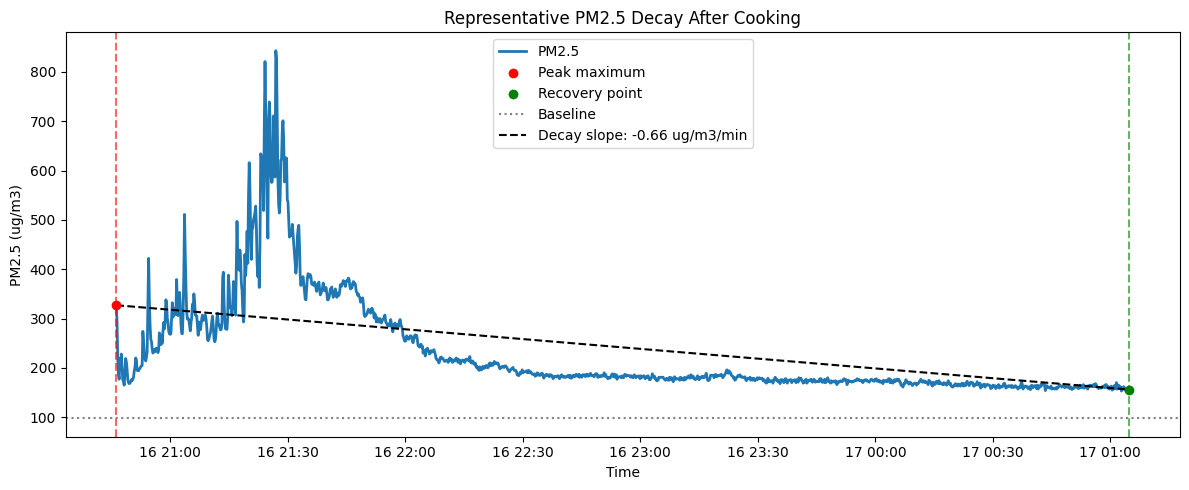

In [23]:
# Call the function
decay_rate_after_cooking(kitchen_df=kitchen_df)

## Spatial Gradient Plot
- Compare mean PM2.5 across rooms
- Compare peak intensity across rooms
- Show attenuation (reduction %) from kitchen outward
- Visualize gradient clearly

#### Steps:
- Combine All Room Data
  - Add column `Room` to all 3 Kitchen, Hall, Bedroom
  - Make sure that data is per minute to make sure that `DateTime` is common accroce all 3
- Calculate Room-Wise Summary
  - Average exposure
  - Maximum spike
  - Variability
- Calculate Gradient Strength
- Create Spatial Gradient Plot
  - Filter only cooking periods
  - Group them on column `Room` and average out `pm2.5atm`
  - Plot this
- Plot Time Synchronized Gradient
  - Create Pivot table with index=`DateTime`, columns=`Room`, and value=`pm2.5atm `
  - Then compute:
    - kitchen - hall
    - hall - bedroom

In [24]:
def spatial_gradient_plot(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError('kitchen_df is None')
    if hall_df is None:
        raise ValueError('hall_df is None')
    if bedroom_df is None:
        raise ValueError('bedroom_df is None')
    
    # Create list of data frame of all 3 rooms with columns `DateTime` and `pm2.5atm`
    bedroom_df_gradient = bedroom_df[["DateTime", "pm2.5atm"]].copy()
    hall_df_gradient = hall_df[["DateTime", "pm2.5atm"]].copy()
    kitchen_df_gradient = kitchen_df[["DateTime", "pm2.5atm"]].copy()
    # Remove outliers
    bedroom_df_gradient = remove_outliers_iqr(bedroom_df_gradient, 'pm2.5atm', 200)
    hall_df_gradient = remove_outliers_iqr(hall_df_gradient, 'pm2.5atm', 1500)
    kitchen_df_gradient = remove_outliers_iqr(kitchen_df_gradient, 'pm2.5atm', 1500)
    # Convert data to per minute form per 10 or 11 seconds
    bedroom_df_gradient['DateTime'] = bedroom_df_gradient['DateTime'].dt.floor('min')
    hall_df_gradient['DateTime'] = hall_df_gradient['DateTime'].dt.floor('min')
    kitchen_df_gradient['DateTime'] = kitchen_df_gradient['DateTime'].dt.floor('min')
    # Group by DateTime and take mean
    bedroom_df_gradient = bedroom_df_gradient.groupby(bedroom_df_gradient['DateTime'], as_index=False).mean().reset_index()
    hall_df_gradient = hall_df_gradient.groupby(hall_df_gradient['DateTime'], as_index=False).mean().reset_index()
    kitchen_df_gradient = kitchen_df_gradient.groupby(kitchen_df_gradient['DateTime'], as_index=False).mean().reset_index()
    # Add Room Column
    bedroom_df_gradient["Room"] = "Bedroom"
    hall_df_gradient["Room"] = "Hall"
    kitchen_df_gradient["Room"] = "Kitchen"
    # Combine all three dataframes
    combined_df = pd.concat([kitchen_df_gradient, hall_df_gradient, bedroom_df_gradient])

    # Calculate room wise summary `mean`, `max`, `min`, `std`
    room_summary = combined_df.groupby("Room")["pm2.5atm"].agg(["mean", "max", "min", "std"])
    print("Room-wise Summary of PM2.5 Levels:")
    print(room_summary)

    # Calculate Gradient Strength (kitchen to hall and kitchen to bedroom)
    kitchen_mean = room_summary.loc["Kitchen", "mean"]
    hall_mean = room_summary.loc["Hall", "mean"]
    bedroom_mean = room_summary.loc["Bedroom", "mean"]
    gradient_kh = ((kitchen_mean - hall_mean) / kitchen_mean) * 100  # in percentage
    gradient_kb = ((kitchen_mean - bedroom_mean) / kitchen_mean) * 100  # in percentage
    print(f"\nGradient strength reduction from Kitchen to Hall: {gradient_kh:.2f}%")
    print(f"Gradient strength reduction from Kitchen to Bedroom: {gradient_kb:.2f}%")

    # Create Spatial Gradient Plot: During Cooking Only
    # Classify periods as cooking or non-cooking
    combined_df["Period"] = combined_df["DateTime"].dt.time.apply(classify_period_simple)
    combined_df = combined_df[combined_df["Period"] != "Non-Cooking"]
    # Group by Room and take mean
    spatial_gradient_df = combined_df.groupby(["Room"])["pm2.5atm"].mean().reset_index()
    # Plot this
    plt.figure(figsize=(8, 5))
    bars = plt.bar(spatial_gradient_df["Room"], spatial_gradient_df["pm2.5atm"], color=['red', 'orange', 'yellow'])
    plt.title("Spatial Gradient of PM2.5 During Cooking Periods")
    plt.xlabel("Room")
    plt.ylabel("Average PM2.5 (ug/m3)")
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom')
    plt.tight_layout()
    # Save plot
    os.makedirs(f"{PLOT_DIR}/Spatial_Gradient_Plot", exist_ok=True)
    plt.savefig(f"{PLOT_DIR}/Spatial_Gradient_Plot/Spatial_Gradient_During_Cooking.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Plot Time Synchronized Gradient
    pivot_df = combined_df.pivot_table(index="DateTime", columns="Room", values="pm2.5atm")
    # Compute differences
    pivot_df["Kitchen-Hall"] = pivot_df["Kitchen"] - pivot_df["Hall"]
    pivot_df["Hall-Bedroom"] = pivot_df["Hall"] - pivot_df["Bedroom"]
    # Plot this diffrence over time
    plt.figure(figsize=(15, 5))
    plt.plot(pivot_df.index, pivot_df["Kitchen-Hall"], label="Kitchen-Hall", marker='o')
    plt.plot(pivot_df.index, pivot_df["Hall-Bedroom"], label="Hall-Bedroom", marker='s')
    plt.title("Temporal Gradient of PM2.5 Between Rooms")
    plt.xlabel("Time")
    plt.ylabel("Difference in PM2.5 (ug/m3)")
    plt.legend()
    plt.tight_layout()
    # Save plot
    os.makedirs(f"{PLOT_DIR}/Spatial_Gradient_Plot", exist_ok=True)
    plt.savefig(f"{PLOT_DIR}/Spatial_Gradient_Plot/Temporal_Gradient.png", dpi=300, bbox_inches="tight")
    plt.show()

Room-wise Summary of PM2.5 Levels:
               mean     max        min        std
Room                                             
Bedroom   75.197451   200.0  40.333333  26.418443
Hall     104.557389  1444.0  25.200000  70.466983
Kitchen  101.192162  1477.0  24.200000  66.227451

Gradient strength reduction from Kitchen to Hall: -3.33%
Gradient strength reduction from Kitchen to Bedroom: 25.69%


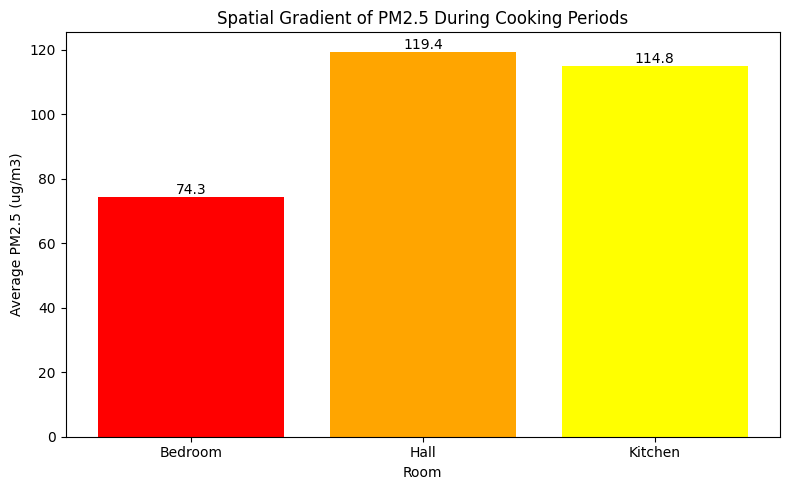

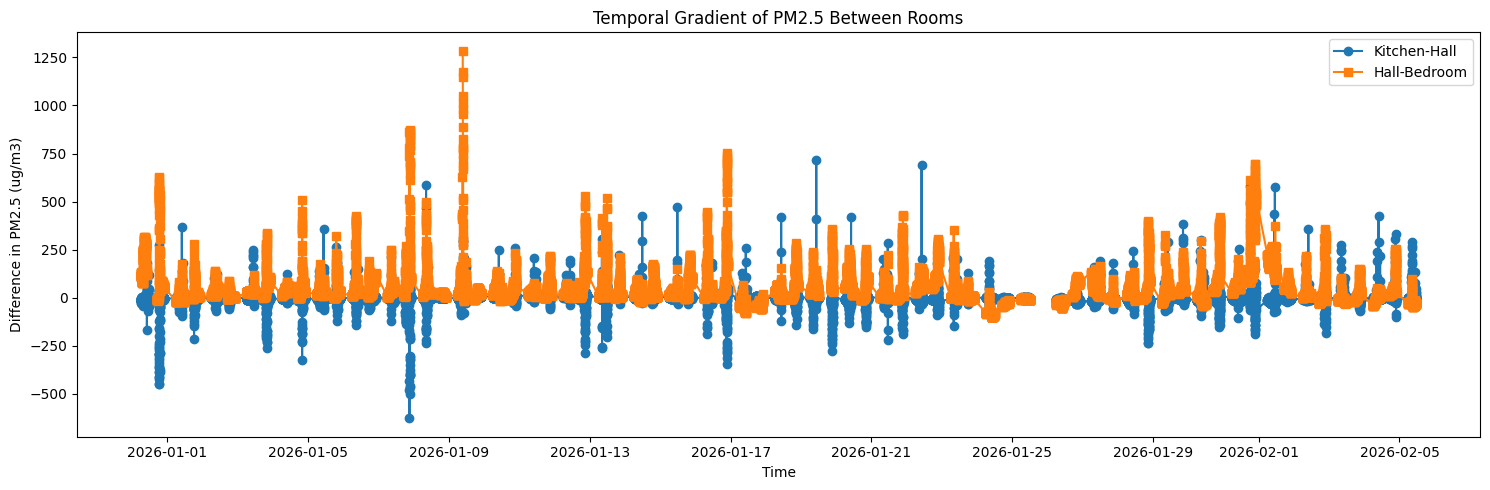

In [25]:
# Call the function
spatial_gradient_plot(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

## Particle Size Distribution (Source Characterization)
- Using : `c_300`, `c_500`, `c_1000`, `c_2500`, `c_5000`, `c_10000`
- Compare mean counts across rooms
- Fine particles dominance => combustion source
- Coarse particles dominance => dust/resuspension

In [26]:
def particle_size_distribution(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError('kitchen_df is None')
    if hall_df is None:
        raise ValueError('hall_df is None')
    if bedroom_df is None:
        raise ValueError('bedroom_df is None')
    
    # Create list of `DateTime`, `c_300`, `c_500`, `c_1000`, `c_2500`, `c_5000`, `c_10000` for each room
    kitchen_df_particals = kitchen_df[["c_300", "c_500", "c_1000", "c_2500", "c_5000", "c_10000"]].copy()
    hall_df_particals = hall_df[["c_300", "c_500", "c_1000", "c_2500", "c_5000", "c_10000"]].copy()
    bedroom_df_particals = bedroom_df[["c_300", "c_500", "c_1000", "c_2500", "c_5000", "c_10000"]].copy()

    # Add room column
    kitchen_df_particals["Room"] = "Kitchen"
    hall_df_particals["Room"] = "Hall"
    bedroom_df_particals["Room"] = "Bedroom"

    # Combine all three dataframes
    combined_df_particals = pd.concat([kitchen_df_particals, hall_df_particals, bedroom_df_particals])

    # Compare mean counts across all room
    particle_summary = combined_df_particals.groupby("Room").mean()
    print("Mean Particle Counts Across Rooms:")
    print(particle_summary)

In [27]:
# Call the function
particle_size_distribution(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)

Mean Particle Counts Across Rooms:
               c_300        c_500       c_1000     c_2500       c_5000  \
Room                                                                     
Bedroom  4720.980161  3813.537391   677.817590  35.389993  3813.537619   
Hall     5025.575467  4602.370257  1063.136781  62.050988  4602.370257   
Kitchen  4510.066771  4001.645821   936.768259  69.695140  4001.645821   

          c_10000  
Room               
Bedroom  0.004099  
Hall     1.962173  
Kitchen  2.380598  


## Correlation heatmap for each room

In [28]:
def correlation_heatmap(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError('kitchen_df is None')
    if hall_df is None:
        raise ValueError('hall_df is None')
    if bedroom_df is None:
        raise ValueError('bedroom_df is None')

    # Create heatmap for kitchen
    kitchen_corr = kitchen_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(kitchen_corr, annot=True, cmap="coolwarm", center=0)
    plt.title("Kitchen Correlation Heatmap")
    plt.tight_layout()
    os.makedirs(f"{PLOT_DIR}/Correlation_Heatmap", exist_ok=True)
    plt.savefig(
        f"{PLOT_DIR}/Correlation_Heatmap/Kitchen_Correlation_Heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Create heatmap for kitchen for only pms amd counts
    kitchen_pms_counts_corr = kitchen_df[
        [
            "PM1", "PM2.5", "PM10", "pm1atm", "pm2.5atm", "pm10atm",
            "c_300", "c_500", "c_1000", "c_2500", "c_5000", "c_10000",
        ]
    ].copy().corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(kitchen_pms_counts_corr, annot=True, cmap="coolwarm", center=0)
    plt.title("Kitchen Pms and counts Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(
        f"{PLOT_DIR}/Correlation_Heatmap/Kitchen_pms_counts_Correlation_Heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Create heatmap for hall
    hall_corr = hall_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(hall_corr, annot=True, cmap="coolwarm", center=0)
    plt.title("Hall Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(
        f"{PLOT_DIR}/Correlation_Heatmap/Hall_Correlation_Heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    # Create heatmap for hall for only pms amd counts
    hall_pms_counts_corr = hall_df[
        [
            "PM1", "PM2.5", "PM10", "pm1atm", "pm2.5atm", "pm10atm",
            "c_300", "c_500", "c_1000", "c_2500", "c_5000", "c_10000",
        ]
    ].copy().corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(hall_pms_counts_corr, annot=True, cmap="coolwarm", center=0)
    plt.title("Hall Pms and counts Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(
        f"{PLOT_DIR}/Correlation_Heatmap/Hall_pms_counts_Correlation_Heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Create heatmap for hall
    bedroom_corr = bedroom_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(bedroom_corr, annot=True, cmap="coolwarm", center=0)
    plt.title("Bedroom Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(
        f"{PLOT_DIR}/Correlation_Heatmap/Bedroom_Correlation_Heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Create heatmap for bedroom for only pms amd counts
    bedroom_pms_counts_corr = bedroom_df[
        [
            "PM1", "PM2.5", "PM10", "pm1atm", "pm2.5atm", "pm10atm",
            "c_300", "c_500", "c_1000", "c_2500", "c_5000", "c_10000",
        ]
    ].copy().corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(bedroom_pms_counts_corr, annot=True, cmap="coolwarm", center=0)
    plt.title("Bedrrom Pms and counts Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(
        f"{PLOT_DIR}/Correlation_Heatmap/Bedroom_pms_counts_Correlation_Heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

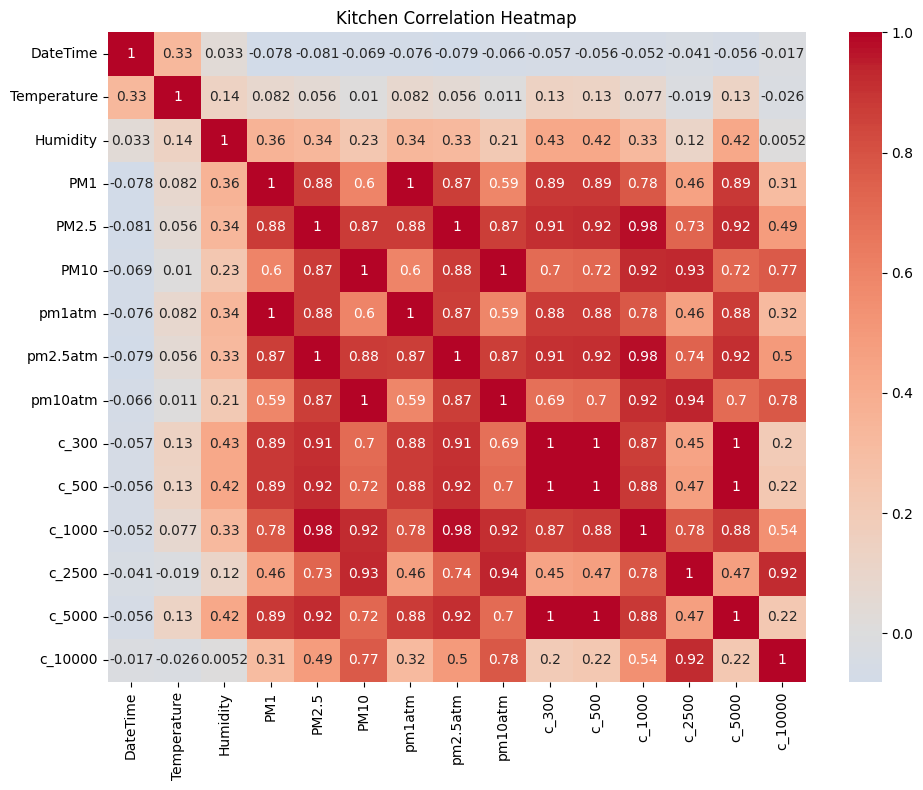

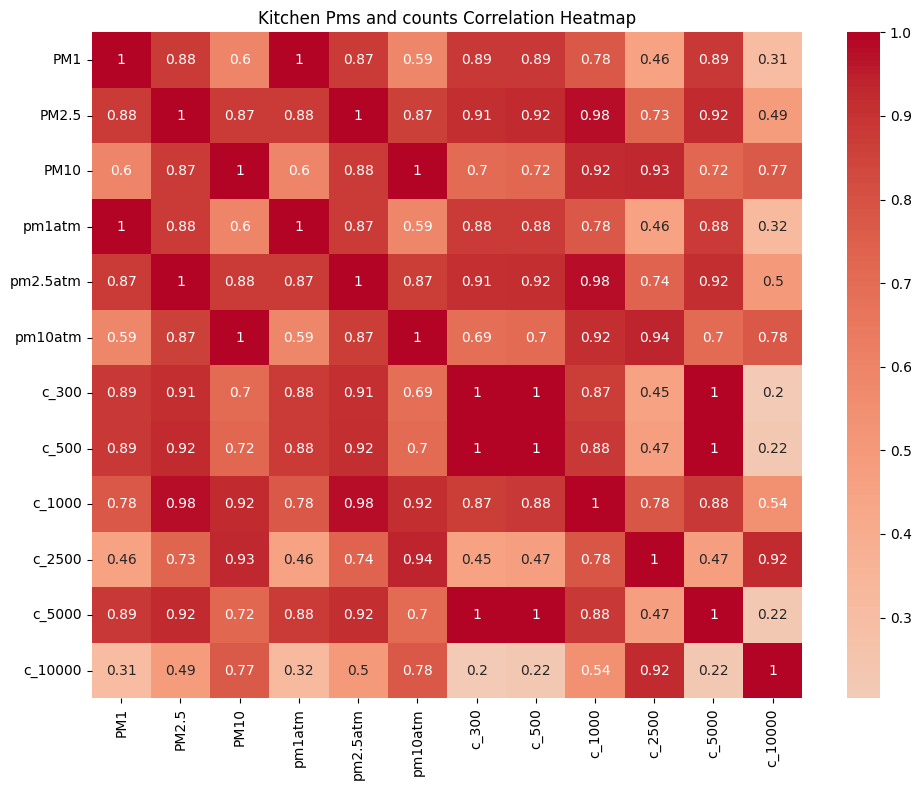

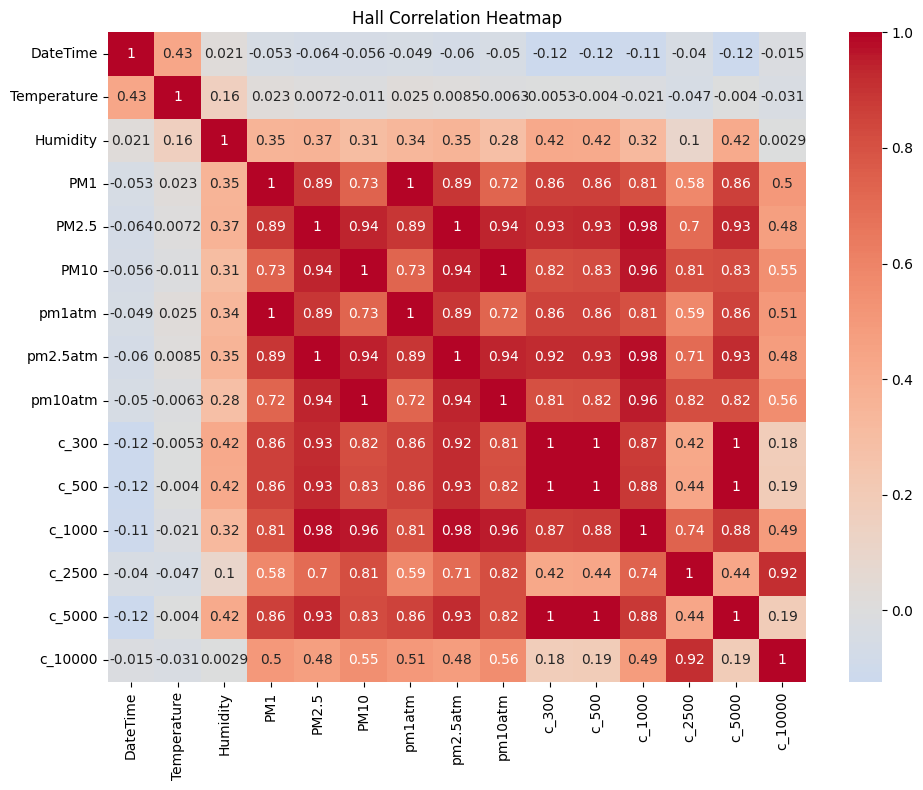

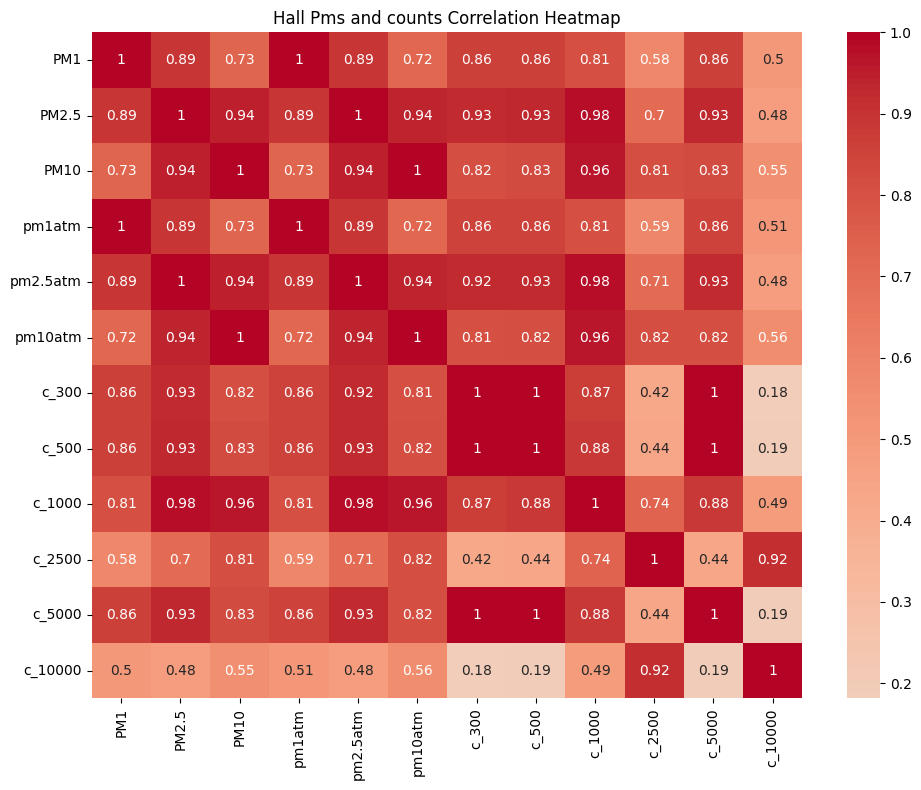

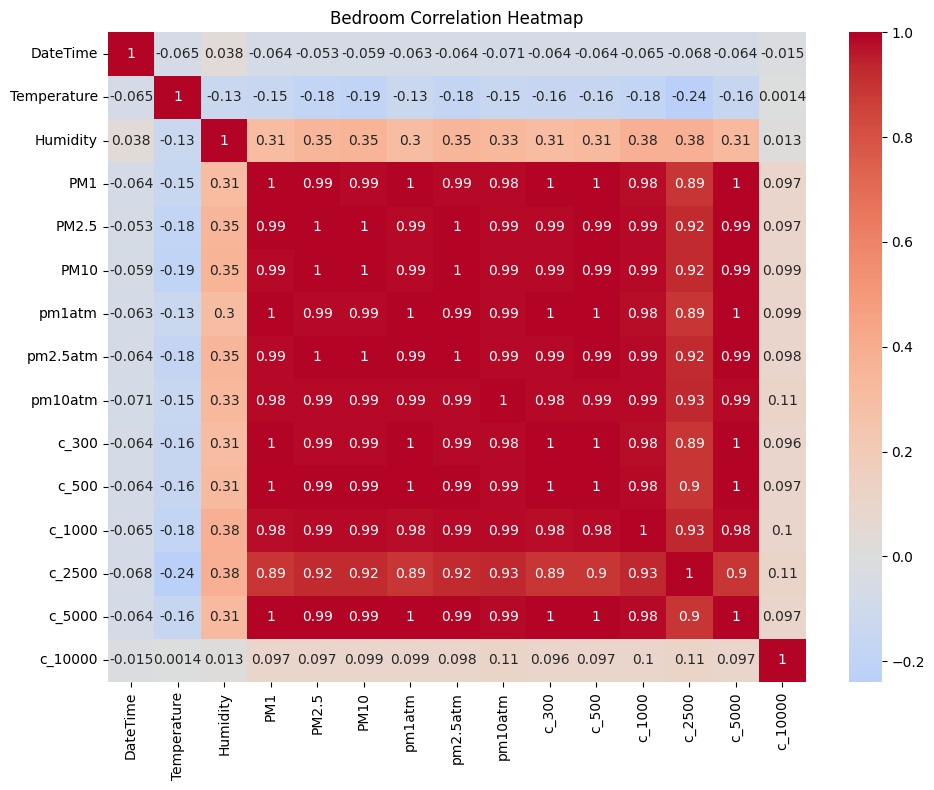

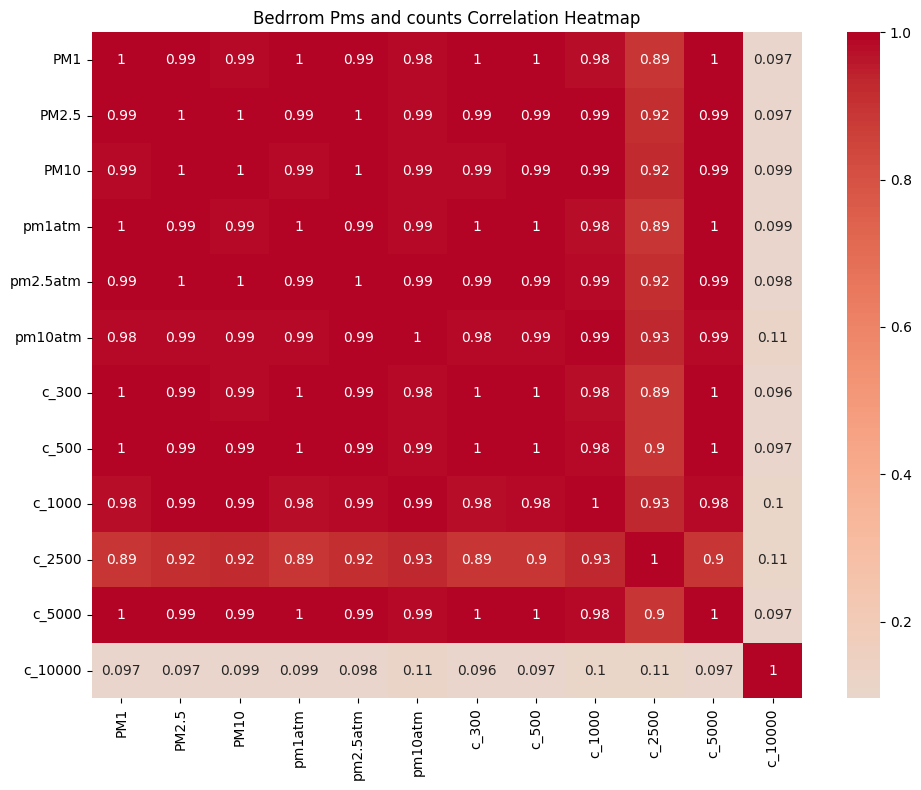

In [29]:
# Call the function
correlation_heatmap(kitchen_df=kitchen_df, hall_df=hall_df, bedroom_df=bedroom_df)